In [12]:
import os
import cv2
from tqdm import tqdm
import numpy as np
from scipy import ndimage
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from scipy.ndimage import zoom
from sklearn.utils import shuffle
from scipy import signal
from xgboost import XGBClassifier
import pickle
from skimage.filters import threshold_otsu
from skimage.segmentation import clear_border
from skimage.morphology import closing, square
from scipy import ndimage
import matplotlib.patches as mpatches
from skimage.color import label2rgb
from skimage.measure import label, regionprops,find_contours
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.utils import shuffle
import matplotlib.pyplot as plt
from lazypredict.Supervised import LazyClassifier
from skimage.draw import polygon_perimeter
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import ZeroPadding2D,UpSampling2D, MaxPool3D,Input, Concatenate,Multiply,LayerNormalization, Lambda, SeparableConv2D,MaxPooling2D,GlobalMaxPooling2D,GlobalAveragePooling2D,Dropout
from keras import backend as K
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2
from tensorflow.keras.applications import ResNet50, ResNet101,EfficientNetB7,Xception,VGG19,MobileNetV2,ResNet101V2
from tensorflow.keras.applications import EfficientNetB7
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.metrics import Recall, Precision, Accuracy
from tensorflow.keras import backend as K

# Define the directories
dir_normal = 'C:\\Users\\yaswa\\learn\\Neural_networks\\research_ws\\Brain_ct_scan\\mal_dataset_thick\\mal_normal'
dir_thin = 'C:\\Users\\yaswa\\learn\\Neural_networks\\research_ws\\Brain_ct_scan\\mal_dataset_thick\\mal_acute'
dir_chronic = 'C:\\Users\\yaswa\\learn\\Neural_networks\\research_ws\\Brain_ct_scan\\mal_dataset_thick\\mal_chronic'

dir_train='C:/Users/mahesh.inamdar/Desktop/codes/classes/run/train'
dir_test='C:/Users/mahesh.inamdar/Desktop/codes/classes/run/test'

def preprocessing(im1):
    im1[im1==255]=0
    im2 = cv2.medianBlur(im1,51)
    th,img2=cv2.threshold(im2, 10, 255, cv2.THRESH_BINARY)
    img2[img2==255]=1
    image=np.multiply(img2,im1)
    thresh = threshold_otsu(image)
    bw = closing(image > thresh, square(3))
    cleared = clear_border(bw)
    label_image = label(cleared)
    image_label_overlay = label2rgb(label_image, image=image, bg_label=0)
    contours = find_contours(image, 0.8)
    bounding_boxes = []
    
    for contour in contours:
        Xmin = np.min(contour[:,0])
        Xmax = np.max(contour[:,0])
        Ymin = np.min(contour[:,1])
        Ymax = np.max(contour[:,1])

        bounding_boxes.append([Xmin, Xmax, Ymin, Ymax])

    with_boxes  = np.copy(image)

    for box in bounding_boxes:
        #[Xmin, Xmax, Ymin, Ymax]
        r = [box[0],box[1],box[1],box[0], box[0]]
        c = [box[3],box[3],box[2],box[2], box[3]]
        rr, cc = polygon_perimeter(r, c, with_boxes.shape)
        with_boxes[rr, cc] = 5 #set color white
        
    #fig, ax = plt.subplots(figsize=(10, 6))
    poly=[]
    
    for region in regionprops(label_image):
        # take regions with large enough areas
        if region.area >= 10000:
                # draw rectangle around segmented coins
            minr, minc, maxr, maxc = region.bbox
            rect = mpatches.Rectangle((minc, minr), maxc - minc, maxr - minr,
                                          fill=False, edgecolor='red', linewidth=2)
            poly.append(region.bbox)
            #ax.add_patch(rect)

    try:
        a,b,c,d=poly[-1]
        return cv2.resize(image[a:c,b:d], (512,512), interpolation= cv2.INTER_LINEAR)
    except IndexError:
        return cv2.resize(image, (512,512), interpolation= cv2.INTER_LINEAR)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

import numpy as np
from math import atan2, pi, atan

def steerable_pyramid(image, levels, orientations):
    if isinstance(image, tuple):
        height, width = image[0].shape[:2]
    else:
        height, width = image.shape[:2]
    pyramid = []

    for level in range(levels):
        pyramid_level = []
        for orientation in range(orientations):
            theta = orientation * np.pi / orientations

            # Create a filter at the specified orientation
            try:
                filt = steerable_filter(height, width, theta)
            except ValueError:
                continue

            # Convolve the image with the filter
            response = signal.convolve2d(image, filt, mode='same', boundary='symm')

            # Downsample the response
            response = zoom(response, 0.5)

            pyramid_level.append(response)

        pyramid.append(pyramid_level)
        image = zoom(image, 0.5)

    return pyramid

def steerable_filter(height, width, theta):
    sigma = 3
    gamma = 1
    scale = 1

    # Create Gaussian derivative filters
    gauss = signal.gaussian(height, std=sigma)
    gauss_d = np.gradient(gauss)

    # Construct the filter at the specified orientation
    x, y = np.meshgrid(np.arange(width), np.arange(height))
    x = x - (width - 1) / 2
    y = y - (height - 1) / 2
    x_theta = x * np.cos(theta) + y * np.sin(theta)
    y_theta = -x * np.sin(theta) + y * np.cos(theta)
    r_theta = np.sqrt(x_theta**2 + y_theta**2)
    filt = scale * np.exp(-0.5 * ((r_theta**2) / (sigma**2))**gamma) * np.cos(r_theta - theta)

    # Normalize the filter
    filt /= np.sum(np.abs(filt))

    return filt

def wld_descriptor(image, num_neighbors=8, num_orientations=8,num_diff_exc_bins=None, num_segments=6, num_bins_per_segment=3):
    """
    Compute the Weber Local Descriptor (WLD) for the given image.
    
    Args:
        image (numpy.ndarray): Input image.
        num_neighbors (int): Number of neighbors to consider for differential excitation.
        num_orientations (int): Number of dominant orientations to quantize the gradients.
        
    Returns:
        numpy.ndarray: WLD descriptor histogram.
    """
    # Compute differential excitation
    diff_excitation = differential_excitation(image, num_neighbors)
    segment_min = diff_excitation.min()
    segment_max = diff_excitation.max()
    segment_bins = np.linspace(segment_min, segment_max, endpoint=True)
    diff_excitation_hist, _ = np.histogram(diff_excitation, bins=segment_bins, density=True)
    
    # Compute orientation
    orientation = structure_tensor_orientation(image, num_orientations)
    segment_min = orientation.min()
    segment_max = orientation.max()
    segment_bins = np.linspace(segment_min, segment_max, endpoint=True)
    orientation_hist, _ = np.histogram(orientation, bins=segment_bins, density=True)
    
    diff_excitation = np.nan_to_num(diff_excitation, nan=0.0)

    # Set default value for num_diff_exc_bins if None
    num_diff_exc_bins = int(np.max(diff_excitation) - np.min(diff_excitation)) + 1
    # Combine differential excitation and orientation into the WLD descriptor histogram
    if num_diff_exc_bins is None:
        num_diff_exc_bins = int(np.max(diff_excitation) - np.min(diff_excitation)) + 1
    num_orientations=8
    #print('check 1',num_orientations)
    wld_2d_hist = np.zeros((num_diff_exc_bins, num_orientations))
    for y in range(image.shape[0]):
        for x in range(image.shape[1]):
            j = int(diff_excitation[y, x])
            t = int(orientation[y, x])
            wld_2d_hist[j, t] += 1

    # Encode the 2D histogram into the 1D histogram H
    wld_1d_hist = encode_2d_to_1d_histogram(wld_2d_hist, num_segments, num_bins_per_segment)

    return np.array(np.ravel(wld_2d_hist))

def encode_2d_to_1d_histogram(wld_2d_hist, num_segments, num_bins_per_segment):
    """
    Encode the 2D WLD histogram into a 1D histogram.

    Args:
        wld_2d_hist (numpy.ndarray): 2D WLD histogram.
        num_segments (int): Number of segments to divide the differential excitation range.
        num_bins_per_segment (int): Number of bins within each differential excitation segment.

    Returns:
        numpy.ndarray: 1D WLD descriptor histogram.
    """
    num_orientations = wld_2d_hist.shape[1]
    diff_exc_range = np.pi
    segment_width = diff_exc_range / num_segments

    # Divide each column (orientation) into segments and concatenate
    wld_1d_hist = []
    for t in range(num_orientations):
        column_hist = wld_2d_hist[:, t]
        segments = np.array_split(column_hist, num_segments)
        segment_min = np.min(np.ravel(wld_2d_hist))
        segment_max = np.max(np.ravel(wld_2d_hist))
        for segment in segments:
            if segment.size > 0:  # Check if segment is not empty
                segment_bins = np.linspace(segment_min, segment_max, num_bins_per_segment + 1, endpoint=True)
                segment_hist, _ = np.histogram(segment, bins=segment_bins, density=True)
                segment_hist[np.isnan(segment_hist)] = 0  # Replace NaN values with 0
                segment_hist[np.isinf(segment_hist)] = 0
                wld_1d_hist.extend(segment_hist)
            else:
                # If segment is empty, assign default values to the corresponding bins
                wld_1d_hist.extend([0.0] * num_bins_per_segment)

    return np.array(wld_1d_hist)

def differential_excitation(image, num_neighbors):
    """
    Compute the differential excitation component of the WLD descriptor.
    
    Args:
        image (numpy.ndarray): Input image.
        num_neighbors (int): Number of neighbors to consider.
        
    Returns:
        numpy.ndarray: Differential excitation values.
    """
    diff_excitation = np.zeros_like(image, dtype=np.float64)
    image=np.asarray(image)
    print(image.shape)
    for y in range(image.shape[0]):
        for x in range(image.shape[1]):
            neighbors = []
            for dy in [-1, 0, 1]:
                for dx in [-1, 0, 1]:
                    if dy == dx == 0:
                        continue
                    ny, nx = y + dy, x + dx
                    if 0 <= ny < image.shape[0] and 0 <= nx < image.shape[1]:
                        neighbors.append(image[ny, nx])
            neighbors = np.array(neighbors)
            diff_excitation[y, x] = np.arctan(np.sum(neighbors - image[y, x]) / (image[y, x]+1e-6))
    return diff_excitation

def structure_tensor_orientation(image, num_orientations=8,window_size=3, sigma=1.0):
    """
    Compute the orientation component of the WLD descriptor using the structure tensor approach.

    Args:
        image (numpy.ndarray): Input image.
        window_size (int): Size of the local neighborhood window for computing the structure tensor.
        sigma (float): Standard deviation for Gaussian kernel used for smoothing.

    Returns:
        numpy.ndarray: Orientations computed using the structure tensor.
    """
    image=np.array(image)
    print('Orientation',image.shape)
    # Compute gradients
    sobel_x = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=3)
    sobel_y = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=3)

    # Compute structure tensor components
    ix2 = sobel_x ** 2
    iy2 = sobel_y ** 2
    ixy = sobel_x * sobel_y

    # Smooth the structure tensor components
    kernel = cv2.getGaussianKernel(window_size, sigma)
    ix2 = cv2.sepFilter2D(ix2, -1, kernel, kernel)
    iy2 = cv2.sepFilter2D(iy2, -1, kernel, kernel)
    ixy = cv2.sepFilter2D(ixy, -1, kernel, kernel)

    # Compute eigenvalues and orientations
    orientation = np.zeros_like(image, dtype=np.float64)
    num_orientations=8
    for y in range(image.shape[0]):
        for x in range(image.shape[1]):
            tensor = np.array([[ix2[y, x], ixy[y, x]], [ixy[y, x], iy2[y, x]]])
            print('tensor',np.shape(tensor))
            tensor=np.reshape(tensor, (32,2,2))
            eigenvalues, eigenvectors = np.linalg.eig(tensor)
            orientation[y, x] = np.arctan2(eigenvectors[1, 0], eigenvectors[0, 0])
    
    if num_orientations is not None:
        orientation = (orientation % (2 * pi)) * num_orientations / (2 * pi)
        return orientation.astype(int)
    else:
        return orientation


def get_label(dir):
    if 'NS' in dir:
        return 0
    elif 'AS' in dir:
        return 1
    elif 'CS' in dir:
        return 2
    
def resize_image(image, target_size=(64, 64)):
    resized_image = cv2.resize(image, target_size)
    return resized_image

def extract_patches(image, patch_size):
    patches = []
    height, width = image.shape[:2]
    for y in range(0, height - patch_size[0] + 1, patch_size[0]):
        for x in range(0, width - patch_size[1] + 1, patch_size[1]):
            patch = image[y:y+patch_size[0], x:x+patch_size[1]]
            patches.append(patch)
    return np.array(patches)

ImportError: DLL load failed while importing _pywrap_tfe: The specified procedure could not be found.

In [ ]:
def model(input_1):
    Efficient=ResNet50(include_top=False,weights="imagenet",input_tensor=input_1,input_shape=None,pooling=None,classes=1000)
    Layer1=GlobalAveragePooling2D()(Efficient.get_layer('conv5_block3_out').output)
    D1 = Dense 
    return Model(input_1,Layer1)

inputs1=tf.keras.Input(shape=(512,512,3))
model=model(inputs1)

In [13]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.applications import ResNet50

ImportError: DLL load failed while importing _pywrap_tfe: The specified procedure could not be found.

In [3]:
import os
import cv2
from tqdm import tqdm
import numpy as np
import math
from scipy import ndimage
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from scipy.ndimage import zoom
from sklearn.utils import shuffle
from scipy import signal
from xgboost import XGBClassifier
import pickle
from skimage.filters import threshold_otsu
from skimage.segmentation import clear_border
from skimage.morphology import closing, square
from scipy import ndimage
import matplotlib.patches as mpatches
from skimage.color import label2rgb
from skimage.measure import label, regionprops,find_contours
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.utils import shuffle
import matplotlib.pyplot as plt
from lazypredict.Supervised import LazyClassifier
from skimage.draw import polygon_perimeter


def preprocessing(im1):
    im1[im1==255]=0
    im2 = cv2.medianBlur(im1,51)
    th,img2=cv2.threshold(im2, 10, 255, cv2.THRESH_BINARY)
    img2[img2==255]=1
    image=np.multiply(img2,im1)
    thresh = threshold_otsu(image)
    bw = closing(image > thresh, square(3))
    cleared = clear_border(bw)
    label_image = label(cleared)
    image_label_overlay = label2rgb(label_image, image=image, bg_label=0)
    contours = find_contours(image, 0.8)
    bounding_boxes = []
    
    for contour in contours:
        Xmin = np.min(contour[:,0])
        Xmax = np.max(contour[:,0])
        Ymin = np.min(contour[:,1])
        Ymax = np.max(contour[:,1])

        bounding_boxes.append([Xmin, Xmax, Ymin, Ymax])

    with_boxes  = np.copy(image)

    for box in bounding_boxes:
        #[Xmin, Xmax, Ymin, Ymax]
        r = [box[0],box[1],box[1],box[0], box[0]]
        c = [box[3],box[3],box[2],box[2], box[3]]
        rr, cc = polygon_perimeter(r, c, with_boxes.shape)
        with_boxes[rr, cc] = 5 #set color white
        
    #fig, ax = plt.subplots(figsize=(10, 6))
    poly=[]
    
    for region in regionprops(label_image):
        # take regions with large enough areas
        if region.area >= 10000:
                # draw rectangle around segmented coins
            minr, minc, maxr, maxc = region.bbox
            rect = mpatches.Rectangle((minc, minr), maxc - minc, maxr - minr,
                                          fill=False, edgecolor='red', linewidth=2)
            poly.append(region.bbox)
            #ax.add_patch(rect)

    try:
        a,b,c,d=poly[-1]
        return cv2.resize(image[a:c,b:d], (512,512), interpolation= cv2.INTER_LINEAR)
    except IndexError:
        return cv2.resize(image, (512,512), interpolation= cv2.INTER_LINEAR)


def ltp_descriptor(image, radius=2, neighbors=8, threshold=3):

    ltp_hist = np.zeros(3 ** neighbors, dtype=np.uint8)
    for y in range(radius, image.shape[0] - radius):
        for x in range(radius, image.shape[1] - radius):
            center = image[y, x]
            code = 0
            for n in range(neighbors):
                x_offset = x + radius * np.cos(2 * math.pi * n / neighbors)
                y_offset = y - radius * np.sin(2 * math.pi * n / neighbors)
                neighbor = image[int(y_offset), int(x_offset)]
                code = code * 3 + (neighbor >= center + threshold) + (neighbor <= center - threshold)
            ltp_hist[code] += 1
    return ltp_hist


image=preprocessing(cv2.imread('C:/Users/mahesh.inamdar/OneDrive - Manipal Academy of Higher Education/PhD/Multiclass Brain Classification using MWLD/Fig Preprocessing/Acute/Original.png',0))
image=cv2.resize(image,(512,512))
LTP=ltp_descriptor(image,radius=2, neighbors=8, threshold=3)


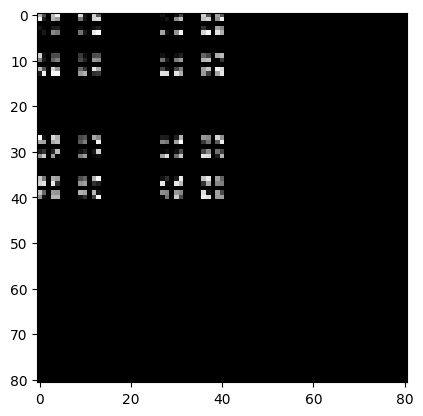

In [6]:
img=np.reshape(LTP,(81,81))
plt.imshow(img,cmap='gray')

True

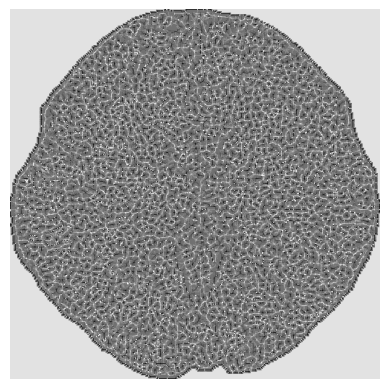

In [27]:
from skimage.feature import local_binary_pattern
from skimage import feature

def extract_lbp_features(img):
    radius = 1 
    n_points = 8 * radius
    lbp = local_binary_pattern(img, n_points, radius, method='default')
    n_bins = int(lbp.max() + 1)
    hist, _ = np.histogram(lbp, density=True, bins=n_bins, range=(0, n_bins))
    return hist

def compute_lbp(image):
    lbp = feature.local_binary_pattern(image, P=8, R=1, method="uniform")
    return lbp

image=preprocessing(cv2.imread('C:/Users/mahesh.inamdar/OneDrive - Manipal Academy of Higher Education/PhD/Multiclass Brain Classification using MWLD/Fig Preprocessing/Normal/Original.png',0))
image=cv2.resize(image,(512,512))
lbp = compute_lbp(image)
lbp_normalized = np.uint8(255 * (lbp - np.min(lbp)) / np.ptp(lbp))
fm=lbp_normalized.reshape(512,512)
plt.imshow(fm,cmap='gray')
plt.axis('off')
cv2.imwrite('C:/Users/mahesh.inamdar/OneDrive - Manipal Academy of Higher Education/PhD/Multiclass Brain Classification using MWLD/LBP/LBP_Featuremap_normal.png',fm)

True

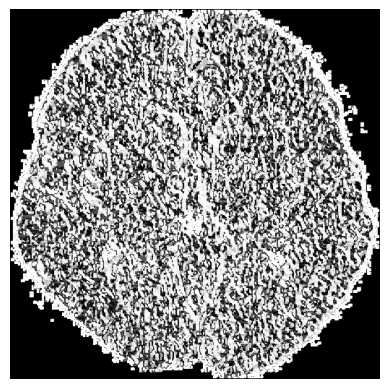

In [30]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# LTP function
def compute_ltp(image, threshold=5):
    rows, cols = image.shape
    ltp_image = np.zeros_like(image, dtype=int)
    
    # Offsets for 8 neighbors (clockwise order around a pixel)
    neighbors = [(-1, -1), (-1, 0), (-1, 1), (0, 1),
                 (1, 1), (1, 0), (1, -1), (0, -1)]
    
    # Iterate over each pixel (excluding borders)
    for i in range(1, rows - 1):
        for j in range(1, cols - 1):
            center_pixel = image[i, j]
            ltp_value = 0
            
            # Compute ternary pattern for the 8 neighbors
            for k, (dx, dy) in enumerate(neighbors):
                neighbor_pixel = image[i + dx, j + dy]
                diff = neighbor_pixel - center_pixel
                
                # Ternary comparison with threshold
                if diff > threshold:
                    bit = 1
                elif diff < -threshold:
                    bit = -1
                else:
                    bit = 0
                
                ltp_value += bit * (3 ** k)  # Ternary pattern to base-3 number
            
            ltp_image[i, j] = ltp_value
    
    return ltp_image

image=preprocessing(cv2.imread('C:/Users/mahesh.inamdar/OneDrive - Manipal Academy of Higher Education/PhD/Multiclass Brain Classification using MWLD/Fig Preprocessing/Acute/Original.png',0))
image=cv2.resize(image,(512,512))
# Compute LTP with a given threshold
threshold = 5  # You can adjust this threshold
ltp = compute_ltp(image, threshold)
# Normalize LTP values for visualization
ltp_normalized = np.uint8(255 * (ltp - np.min(ltp)) / np.ptp(ltp))
fm=ltp_normalized.reshape(512,512)
plt.imshow(fm,cmap='gray')
plt.axis('off')
cv2.imwrite('C:/Users/mahesh.inamdar/OneDrive - Manipal Academy of Higher Education/PhD/Multiclass Brain Classification using MWLD/LTP/LTP_Featuremap_acute.png',fm)

True

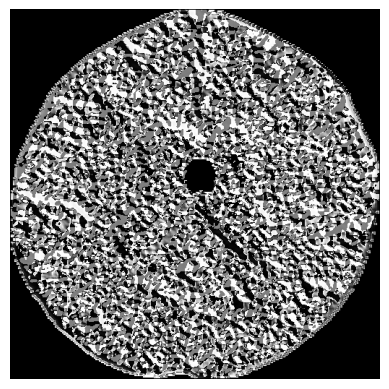

In [26]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def compute_wld_components(image, epsilon=1e-5):
    rows, cols = image.shape
    intensity_difference = np.zeros_like(image, dtype=float)
    gradient_orientation = np.zeros_like(image, dtype=float)
    
    # Offsets for 8 neighbors (clockwise order around a pixel)
    neighbors = [(-1, -1), (-1, 0), (-1, 1), (0, 1),
                 (1, 1), (1, 0), (1, -1), (0, -1)]
    
    for i in range(1, rows - 1):
        for j in range(1, cols - 1):
            center_pixel = image[i, j]
            intensity_diff_sum = 0
            
            # Calculate intensity difference with neighbors
            for dx, dy in neighbors:
                neighbor_pixel = image[i + dx, j + dy]
                intensity_diff_sum += (neighbor_pixel - center_pixel) / (center_pixel + epsilon)
            
            # Average intensity difference
            intensity_difference[i, j] = intensity_diff_sum / len(neighbors)
            
            # Calculate gradient orientation using pixel differences
            dx = image[i + 1, j] - image[i - 1, j]  # Vertical gradient
            dy = image[i, j + 1] - image[i, j - 1]  # Horizontal gradient
            gradient_orientation[i, j] = np.arctan2(dx, dy)
    
    # Convert gradient orientation to degrees and normalize to [0, 360] range
    gradient_orientation = np.rad2deg(gradient_orientation) % 360
    
    return intensity_difference, gradient_orientation

image=preprocessing(cv2.imread('C:/Users/mahesh.inamdar/OneDrive - Manipal Academy of Higher Education/PhD/Multiclass Brain Classification using MWLD/Fig Preprocessing/Chronic/Original.png',0))
image=cv2.resize(image,(512,512))

# Compute Intensity Difference and Gradient Orientation for WLD
intensity_difference, gradient_orientation = compute_wld_components(image)

# Normalize for visualization
intensity_diff_normalized = np.uint8(255 * (intensity_difference - np.min(intensity_difference)) / np.ptp(intensity_difference))
gradient_orientation_normalized = np.uint8(255 * (gradient_orientation - np.min(gradient_orientation)) / np.ptp(gradient_orientation))

# Display original image and WLD feature map
#plt.imshow(intensity_diff_normalized,cmap='gray')
plt.imshow(gradient_orientation_normalized,cmap='gray')
plt.axis('off')
cv2.imwrite('C:/Users/mahesh.inamdar/OneDrive - Manipal Academy of Higher Education/PhD/Multiclass Brain Classification using MWLD/WLD/WLD_Featuremap_chronic_intensity_diff.png',intensity_diff_normalized)
cv2.imwrite('C:/Users/mahesh.inamdar/OneDrive - Manipal Academy of Higher Education/PhD/Multiclass Brain Classification using MWLD/WLD/WLD_Featuremap_chronic_gradient_orientation.png',gradient_orientation_normalized)


True

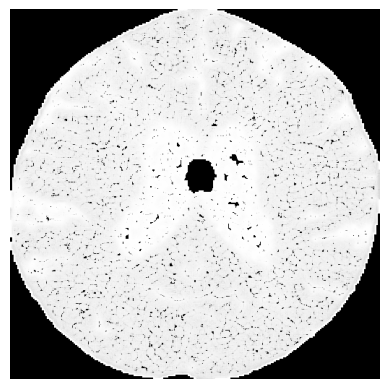

In [20]:
import math
pi=math.pi
def wld_descriptor_mod(image, num_neighbors=8, num_orientations=8,num_diff_exc_bins=None, num_segments=6, num_bins_per_segment=3):
    """
    Compute the Weber Local Descriptor (WLD) for the given image.
    
    Args:
        image (numpy.ndarray): Input image.
        num_neighbors (int): Number of neighbors to consider for differential excitation.
        num_orientations (int): Number of dominant orientations to quantize the gradients.
        
    Returns:
        numpy.ndarray: WLD descriptor histogram.
    """
    # Compute differential excitation
    diff_excitation = differential_excitation(image, num_neighbors)
    segment_min = diff_excitation.min()
    segment_max = diff_excitation.max()
    segment_bins = np.linspace(segment_min, segment_max, endpoint=True)
    diff_excitation_hist, _ = np.histogram(diff_excitation, bins=segment_bins, density=True)
    
    # Compute orientation
    orientation = structure_tensor_orientation(image, num_orientations=8,window_size=3, sigma=1.0)
    segment_min = orientation.min()
    segment_max = orientation.max()
    segment_bins = np.linspace(segment_min, segment_max, endpoint=True)
    orientation_hist, _ = np.histogram(orientation, bins=segment_bins, density=True)
    
    diff_excitation = np.nan_to_num(diff_excitation, nan=0.0)

    # Set default value for num_diff_exc_bins if None
    num_diff_exc_bins = int(np.max(diff_excitation) - np.min(diff_excitation)) + 1
    # Combine differential excitation and orientation into the WLD descriptor histogram
    if num_diff_exc_bins is None:
        num_diff_exc_bins = int(np.max(diff_excitation) - np.min(diff_excitation)) + 1
    num_orientations=8
    wld_2d_hist = np.zeros((num_diff_exc_bins, num_orientations))
    for y in range(image.shape[0]):
        for x in range(image.shape[1]):
            j = int(diff_excitation[y, x])
            t = int(orientation[y, x])
            wld_2d_hist[j, t] += 1

    # Encode the 2D histogram into the 1D histogram H
    wld_1d_hist = encode_2d_to_1d_histogram(wld_2d_hist, num_segments, num_bins_per_segment)

    return np.array(np.ravel(wld_2d_hist))

def encode_2d_to_1d_histogram(wld_2d_hist, num_segments, num_bins_per_segment):
    """
    Encode the 2D WLD histogram into a 1D histogram.

    Args:
        wld_2d_hist (numpy.ndarray): 2D WLD histogram.
        num_segments (int): Number of segments to divide the differential excitation range.
        num_bins_per_segment (int): Number of bins within each differential excitation segment.

    Returns:
        numpy.ndarray: 1D WLD descriptor histogram.
    """
    num_orientations = wld_2d_hist.shape[1]
    diff_exc_range = np.pi
    segment_width = diff_exc_range / num_segments

    # Divide each column (orientation) into segments and concatenate
    wld_1d_hist = []
    for t in range(num_orientations):
        column_hist = wld_2d_hist[:, t]
        segments = np.array_split(column_hist, num_segments)
        segment_min = np.min(np.ravel(wld_2d_hist))
        segment_max = np.max(np.ravel(wld_2d_hist))
        for segment in segments:
            if segment.size > 0:  # Check if segment is not empty
                segment_bins = np.linspace(segment_min, segment_max, num_bins_per_segment + 1, endpoint=True)
                segment_hist, _ = np.histogram(segment, bins=segment_bins, density=True)
                segment_hist[np.isnan(segment_hist)] = 0  # Replace NaN values with 0
                segment_hist[np.isinf(segment_hist)] = 0
                wld_1d_hist.extend(segment_hist)
            else:
                # If segment is empty, assign default values to the corresponding bins
                wld_1d_hist.extend([0.0] * num_bins_per_segment)

    return np.array(wld_1d_hist)

def differential_excitation(image, num_neighbors):
    """
    Compute the differential excitation component of the WLD descriptor.
    
    Args:
        image (numpy.ndarray): Input image.
        num_neighbors (int): Number of neighbors to consider.
        
    Returns:
        numpy.ndarray: Differential excitation values.
    """
    diff_excitation = np.zeros_like(image, dtype=np.float64)
    for y in range(image.shape[0]):
        for x in range(image.shape[1]):
            neighbors = []
            for dy in [-1, 0, 1]:
                for dx in [-1, 0, 1]:
                    if dy == dx == 0:
                        continue
                    ny, nx = y + dy, x + dx
                    if 0 <= ny < image.shape[0] and 0 <= nx < image.shape[1]:
                        neighbors.append(image[ny, nx])
            neighbors = np.array(neighbors)
            diff_excitation[y, x] = np.arctan(np.sum(neighbors - image[y, x]) / (image[y, x]+1e-6))
    return diff_excitation

def structure_tensor_orientation(image, num_orientations=8,window_size=3, sigma=1.0):
    """
    Compute the orientation component of the WLD descriptor using the structure tensor approach.

    Args:
        image (numpy.ndarray): Input image.
        window_size (int): Size of the local neighborhood window for computing the structure tensor.
        sigma (float): Standard deviation for Gaussian kernel used for smoothing.

    Returns:
        numpy.ndarray: Orientations computed using the structure tensor.
    """
    # Compute gradients
    sobel_x = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=3)
    sobel_y = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=3)

    # Compute structure tensor components
    ix2 = sobel_x ** 2
    iy2 = sobel_y ** 2
    ixy = sobel_x * sobel_y

    # Smooth the structure tensor components
    kernel = cv2.getGaussianKernel(window_size, sigma)
    ix2 = cv2.sepFilter2D(ix2, -1, kernel, kernel)
    iy2 = cv2.sepFilter2D(iy2, -1, kernel, kernel)
    ixy = cv2.sepFilter2D(ixy, -1, kernel, kernel)

    # Compute eigenvalues and orientations
    orientation = np.zeros_like(image, dtype=np.float64)
    num_orientations=8
    for y in range(image.shape[0]):
        for x in range(image.shape[1]):
            tensor = np.array([[ix2[y, x], ixy[y, x]], [ixy[y, x], iy2[y, x]]])
            eigenvalues, eigenvectors = np.linalg.eig(tensor)
            orientation[y, x] = np.arctan2(eigenvectors[1, 0], eigenvectors[0, 0])
    
    if num_orientations is not None:
        orientation = (orientation % (2 * pi)) * num_orientations / (2 * pi)
        return orientation.astype(int)
    else:
        return orientation.astype(int)

image=preprocessing(cv2.imread('C:/Users/mahesh.inamdar/OneDrive - Manipal Academy of Higher Education/PhD/Multiclass Brain Classification using MWLD/Fig Preprocessing/Chronic/Original.png',0))
image=cv2.resize(image,(512,512))

# Compute Intensity Difference and Gradient Orientation for WLD
intensity_difference =differential_excitation(image,num_neighbors=8)
gradient_orientation=structure_tensor_orientation(image, num_orientations=8,window_size=3, sigma=1.0)

# Normalize for visualization
intensity_diff_normalized = np.uint8(255 * (intensity_difference - np.min(intensity_difference)) / np.ptp(intensity_difference))
gradient_orientation_normalized = np.uint8(255 * (gradient_orientation - np.min(gradient_orientation)) / np.ptp(gradient_orientation))

# Display original image and WLD feature map
plt.imshow(intensity_diff_normalized,cmap='gray')
plt.axis('off')
cv2.imwrite('C:/Users/mahesh.inamdar/OneDrive - Manipal Academy of Higher Education/PhD/Multiclass Brain Classification using MWLD/Mod WLD/WLD_Featuremap_chronic_intensity_diff.png',intensity_diff_normalized)
cv2.imwrite('C:/Users/mahesh.inamdar/OneDrive - Manipal Academy of Higher Education/PhD/Multiclass Brain Classification using MWLD/Mod WLD/WLD_Featuremap_chronic_gradient_orientation.png',gradient_orientation_normalized)


Saved: C:/Users/mahesh.inamdar/OneDrive - Manipal Academy of Higher Education/PhD/Multiclass Brain Classification using MWLD/Image Pyramid/Discrete Wavelet Pyramid//wavelet_level_1.png
Saved: C:/Users/mahesh.inamdar/OneDrive - Manipal Academy of Higher Education/PhD/Multiclass Brain Classification using MWLD/Image Pyramid/Discrete Wavelet Pyramid//wavelet_level_2.png
Saved: C:/Users/mahesh.inamdar/OneDrive - Manipal Academy of Higher Education/PhD/Multiclass Brain Classification using MWLD/Image Pyramid/Discrete Wavelet Pyramid//wavelet_level_3.png
Saved: C:/Users/mahesh.inamdar/OneDrive - Manipal Academy of Higher Education/PhD/Multiclass Brain Classification using MWLD/Image Pyramid/Discrete Wavelet Pyramid//wavelet_level_4.png


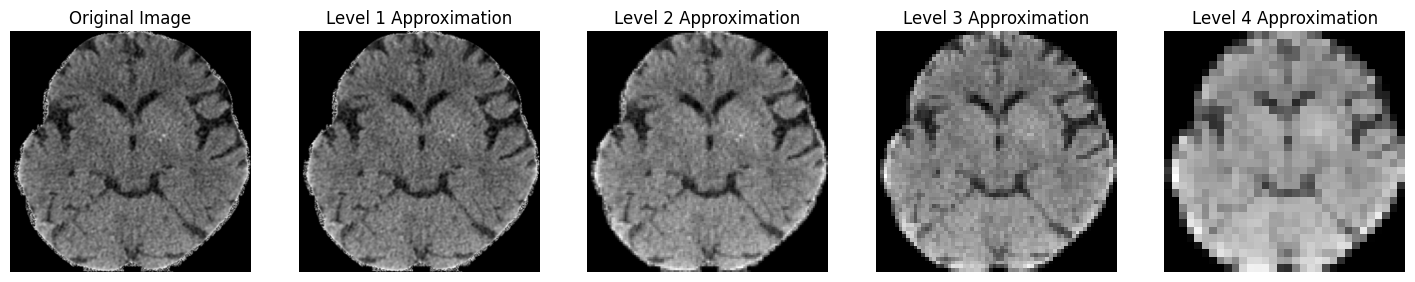

In [44]:
import cv2
import numpy as np
import pywt
import matplotlib.pyplot as plt

# Function to perform wavelet decomposition and save the approximation at each level
def wavelet_pyramid(image, wavelet='haar', level=4, output_dir='./'):
    coeffs = []
    current_image = image
    
    for i in range(level):
        # Perform single-level DWT
        cA, (cH, cV, cD) = pywt.dwt2(current_image, wavelet)
        coeffs.append((cA, (cH, cV, cD)))  # Save approximation and details
        
        # Normalize cA to 0-255 range for saving as an image
        cA_normalized = cv2.normalize(cA, None, 0, 255, cv2.NORM_MINMAX)
        cA_uint8 = np.uint8(cA_normalized)  # Convert to uint8
        
        # Save the approximation image at the current level
        cv2.imwrite(f"{output_dir}/wavelet_level_{i + 1}.png", cA_uint8)
        print(f"Saved: {output_dir}/wavelet_level_{i + 1}.png")
        
        # Next iteration uses approximation as the new image
        current_image = cA
    
    return coeffs

# Function to display the wavelet pyramid
def display_wavelet_pyramid(coeffs, original_image):
    fig, ax = plt.subplots(1, len(coeffs) + 1, figsize=(18, 6))
    
    # Show the original image
    ax[0].imshow(original_image, cmap='gray')
    ax[0].set_title('Original Image')
    ax[0].axis('off')

    # Show the approximation images from each level
    for i, (cA, (cH, cV, cD)) in enumerate(coeffs):
        ax[i + 1].imshow(cA, cmap='gray')
        ax[i + 1].set_title(f'Level {i + 1} Approximation')
        ax[i + 1].axis('off')

    plt.show()

image=preprocessing(cv2.imread('C:/Users/mahesh.inamdar/OneDrive - Manipal Academy of Higher Education/PhD/Multiclass Brain Classification using MWLD/Fig 3/Original.png',0))
image=cv2.resize(image,(512,512))
# Directory to save the output images
output_dir = 'C:/Users/mahesh.inamdar/OneDrive - Manipal Academy of Higher Education/PhD/Multiclass Brain Classification using MWLD/Image Pyramid/Discrete Wavelet Pyramid/'

# Perform 4-level wavelet decomposition and save the approximation images
wavelet = 'haar'  # You can change this to other wavelets like 'db1', 'sym2', etc.
coeffs = wavelet_pyramid(image, wavelet=wavelet, level=4, output_dir=output_dir)

# Display the wavelet pyramid
display_wavelet_pyramid(coeffs, image)



Saved: C:/Users/mahesh.inamdar/OneDrive - Manipal Academy of Higher Education/PhD/Multiclass Brain Classification using MWLD/Image Pyramid/Laplacian//laplacian_level_4.png
Saved: C:/Users/mahesh.inamdar/OneDrive - Manipal Academy of Higher Education/PhD/Multiclass Brain Classification using MWLD/Image Pyramid/Laplacian//laplacian_level_3.png
Saved: C:/Users/mahesh.inamdar/OneDrive - Manipal Academy of Higher Education/PhD/Multiclass Brain Classification using MWLD/Image Pyramid/Laplacian//laplacian_level_2.png
Saved: C:/Users/mahesh.inamdar/OneDrive - Manipal Academy of Higher Education/PhD/Multiclass Brain Classification using MWLD/Image Pyramid/Laplacian//laplacian_level_1.png


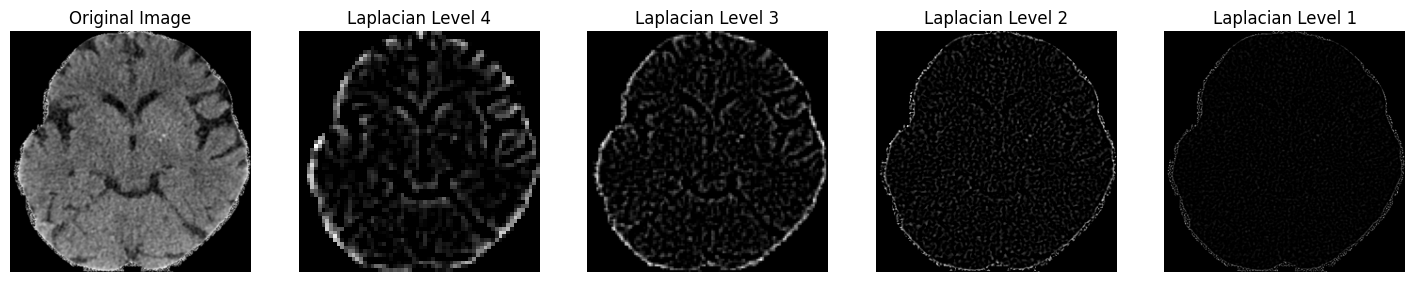

In [45]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Function to build and save the Laplacian Pyramid
def laplacian_pyramid(image, level=4, output_dir=output_dir):
    current_image = image
    gaussian_pyramid = [current_image]
    
    # Build Gaussian pyramid
    for i in range(level):
        current_image = cv2.pyrDown(current_image)  # Downsample the image
        gaussian_pyramid.append(current_image)
    
    laplacian_pyramid = []
    
    for i in range(level, 0, -1):
        # Upsample the current level of Gaussian pyramid
        gaussian_expanded = cv2.pyrUp(gaussian_pyramid[i], dstsize=gaussian_pyramid[i - 1].shape[:2])
        
        # Calculate the Laplacian (difference between current Gaussian level and the expanded one)
        laplacian = cv2.subtract(gaussian_pyramid[i - 1], gaussian_expanded)
        laplacian_pyramid.append(laplacian)
        
        # Normalize and save Laplacian image
        laplacian_normalized = cv2.normalize(laplacian, None, 0, 255, cv2.NORM_MINMAX)
        laplacian_uint8 = np.uint8(laplacian_normalized)
        cv2.imwrite(f"{output_dir}/laplacian_level_{i}.png", laplacian_uint8)
        print(f"Saved: {output_dir}/laplacian_level_{i}.png")
    
    return laplacian_pyramid

# Function to display the Laplacian Pyramid
def display_laplacian_pyramid(laplacian_pyramid, original_image):
    fig, ax = plt.subplots(1, len(laplacian_pyramid) + 1, figsize=(18, 6))

    # Show the original image
    ax[0].imshow(original_image, cmap='gray')
    ax[0].set_title('Original Image')
    ax[0].axis('off')

    # Show the Laplacian pyramid images
    for i, laplacian in enumerate(laplacian_pyramid):
        ax[i + 1].imshow(laplacian, cmap='gray')
        ax[i + 1].set_title(f'Laplacian Level {len(laplacian_pyramid) - i}')
        ax[i + 1].axis('off')

    plt.show()

image=preprocessing(cv2.imread('C:/Users/mahesh.inamdar/OneDrive - Manipal Academy of Higher Education/PhD/Multiclass Brain Classification using MWLD/Fig 3/Original.png',0))
image=cv2.resize(image,(512,512))
# Directory to save the output images
output_dir = 'C:/Users/mahesh.inamdar/OneDrive - Manipal Academy of Higher Education/PhD/Multiclass Brain Classification using MWLD/Image Pyramid/Laplacian/'


# Perform Laplacian pyramid decomposition and save the images
laplacian_pyramid = laplacian_pyramid(image, level=4, output_dir=output_dir)

# Display the Laplacian pyramid
display_laplacian_pyramid(laplacian_pyramid, image)


Saved: C:/Users/mahesh.inamdar/OneDrive - Manipal Academy of Higher Education/PhD/Multiclass Brain Classification using MWLD/Image Pyramid/Gaussian//gaussian_level_1.png
Saved: C:/Users/mahesh.inamdar/OneDrive - Manipal Academy of Higher Education/PhD/Multiclass Brain Classification using MWLD/Image Pyramid/Gaussian//gaussian_level_2.png
Saved: C:/Users/mahesh.inamdar/OneDrive - Manipal Academy of Higher Education/PhD/Multiclass Brain Classification using MWLD/Image Pyramid/Gaussian//gaussian_level_3.png
Saved: C:/Users/mahesh.inamdar/OneDrive - Manipal Academy of Higher Education/PhD/Multiclass Brain Classification using MWLD/Image Pyramid/Gaussian//gaussian_level_4.png


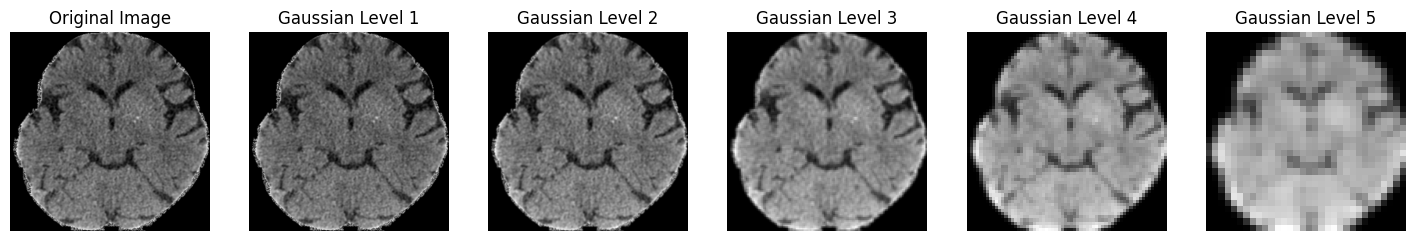

In [46]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Function to build and save the Gaussian Pyramid
def gaussian_pyramid(image, level=4, output_dir='./'):
    gaussian_pyramid = [image]
    current_image = image
    
    for i in range(level):
        # Downsample the image
        current_image = cv2.pyrDown(current_image)
        gaussian_pyramid.append(current_image)
        
        # Normalize and save Gaussian image
        gaussian_normalized = cv2.normalize(current_image, None, 0, 255, cv2.NORM_MINMAX)
        gaussian_uint8 = np.uint8(gaussian_normalized)
        cv2.imwrite(f"{output_dir}/gaussian_level_{i + 1}.png", gaussian_uint8)
        print(f"Saved: {output_dir}/gaussian_level_{i + 1}.png")
    
    return gaussian_pyramid

# Function to display the Gaussian Pyramid
def display_gaussian_pyramid(gaussian_pyramid, original_image):
    fig, ax = plt.subplots(1, len(gaussian_pyramid) + 1, figsize=(18, 6))

    # Show the original image
    ax[0].imshow(original_image, cmap='gray')
    ax[0].set_title('Original Image')
    ax[0].axis('off')

    # Show the Gaussian pyramid images
    for i, gaussian in enumerate(gaussian_pyramid):
        ax[i + 1].imshow(gaussian, cmap='gray')
        ax[i + 1].set_title(f'Gaussian Level {i + 1}')
        ax[i + 1].axis('off')

    plt.show()

image=preprocessing(cv2.imread('C:/Users/mahesh.inamdar/OneDrive - Manipal Academy of Higher Education/PhD/Multiclass Brain Classification using MWLD/Fig 3/Original.png',0))
image=cv2.resize(image,(512,512))
# Directory to save the output images
output_dir = 'C:/Users/mahesh.inamdar/OneDrive - Manipal Academy of Higher Education/PhD/Multiclass Brain Classification using MWLD/Image Pyramid/Gaussian/'


# Perform Gaussian pyramid decomposition and save the images
gaussian_pyramid = gaussian_pyramid(image, level=4, output_dir=output_dir)

# Display the Gaussian pyramid
display_gaussian_pyramid(gaussian_pyramid, image)


In [ ]:
def wld_descriptor_multiscale(image, num_orientations=8, num_diff_exc_bins=None, num_segments=6, num_bins_per_segment=3, num_scales=4):
    """
    Compute the Weber Local Descriptor (WLD) for the given image at multiple scales.

    Args:
        image (numpy.ndarray): Input image.
        num_orientations (int): Number of dominant orientations to quantize.
        num_diff_exc_bins (int, optional): Number of bins for differential excitation values.
            If None, it is set to the maximum intensity value in the image.
        num_segments (int): Number of segments to divide the differential excitation range.
        num_bins_per_segment (int): Number of bins within each differential excitation segment.
        num_scales (int): Number of scales to compute the WLD descriptor.

    Returns:
        numpy.ndarray: 1D concatenated multi-scale WLD descriptor histogram.
    """
    # Create a Gaussian pyramid for the input image
    pyramid = [image.astype(np.float32)]  # Add the original image as the first level
    for _ in range(num_scales - 1):
        pyramid.append(cv2.pyrDown(pyramid[-1]))

    # Compute WLD descriptor at each scale and concatenate
    wld_descriptors = []
    for img in pyramid:
        #print('check',num_orientations)
        wld_descriptors.append(wld_descriptor_mod(image, num_orientations, num_diff_exc_bins, num_segments, num_bins_per_segment))

    wld_multiscale = np.concatenate(wld_descriptors)
    return wld_multiscale

In [7]:
dir_train='C:/Users/mahesh.inamdar/Desktop/codes/classes/run/train'
dir_test='C:/Users/mahesh.inamdar/Desktop/codes/classes/run/test'

print('-----TRAIN-----')
X=np.zeros(shape=(5000,257))
ntr=0
for patients in tqdm(os.listdir(dir_train)):
    for filename in os.listdir(os.path.join(dir_train,patients)):
        img = preprocessing(resize_image(cv2.imread(os.path.join(dir_train, patients,filename), cv2.IMREAD_GRAYSCALE)))
        #patches=extract_patches(img,(256,256))
        con=lbp_descriptor(img)
        X[ntr,0:len(con)]= con
        X[ntr,-1]=get_label(patients)
        ntr+=1
                
print('-----TEST-----')
for patients in tqdm(os.listdir(dir_test)):
    for filename in os.listdir(os.path.join(dir_test,patients)):
        img = preprocessing(resize_image(cv2.imread(os.path.join(dir_test, patients,filename), cv2.IMREAD_GRAYSCALE)))
        #patches=extract_patches(img,(256,256))
        con=lbp_descriptor(img)
        X[ntr,0:len(con)]= con
        X[ntr,-1]=get_label(patients)
        ntr+=1
np.savetxt('C:/Users/mahesh.inamdar/Desktop/LBP.csv', X, delimiter=',')

-----TRAIN-----


100%|███████████████████████████████████████████████████████████████████████████████| 49/49 [5:43:26<00:00, 420.55s/it]


-----TEST-----


100%|███████████████████████████████████████████████████████████████████████████████| 18/18 [4:57:49<00:00, 992.74s/it]


In [16]:
np.savetxt('C:/Users/mahesh.inamdar/Desktop/LTP.csv', X, delimiter=',')

In [4]:
img=ltp_descriptor(preprocessing(resize_image(cv2.imread('C:/Users/mahesh.inamdar/Desktop/codes/classes/run/train/CS_20_thin/CS_20-img-00020-00095.jpg',0),(512,512))))
#patches=extract_patches(img,(256,256))
#con=np.concatenate((ltp_descriptor(patches[0]),ltp_descriptor(patches[1]),
      #                             ltp_descriptor(patches[2]),ltp_descriptor(patches[3])))
np.shape(img)

(6561,)

In [14]:
dirpath='C:/Users/mahesh.inamdar/Desktop/codes/Dental Images'
folders=np.random.choice(os.listdir(dirpath),40)
images=[]
X_train=np.zeros(shape=(200,6561))
y_train=[]
c=0
while c<=200:
    if c>200:
        break
    n=np.random.choice(folders,1)
    img=np.random.choice(os.listdir(os.path.join(dirpath,n[0])),1)
    X_train[c,:]=ltp_descriptor(preprocessing(resize_image(cv2.imread(os.path.join(dirpath,n[0],img[0]),0),(512,512))))
    y_train.append(get_label(n[0]))
    c+=1

IndexError: index 200 is out of bounds for axis 0 with size 200

In [4]:
import os
import cv2
from tqdm import tqdm
import numpy as np
from scipy import ndimage
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from scipy.ndimage import zoom
from sklearn.utils import shuffle
from scipy import signal
from xgboost import XGBClassifier
import pickle
from skimage.filters import threshold_otsu
from skimage.segmentation import clear_border
from skimage.morphology import closing, square
from scipy import ndimage
import matplotlib.patches as mpatches
from skimage.color import label2rgb
from skimage.measure import label, regionprops,find_contours
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.utils import shuffle
import matplotlib.pyplot as plt
from skimage.draw import polygon_perimeter

# Define the directories
dir_normal = 'C:\\Users\\yaswa\\learn\\Neural_networks\\research_ws\\Brain_ct_scan\\mal_dataset_thick\\mal_normal'
dir_thin = 'C:\\Users\\yaswa\\learn\\Neural_networks\\research_ws\\Brain_ct_scan\\mal_dataset_thick\\mal_acute'
dir_chronic = 'C:\\Users\\yaswa\\learn\\Neural_networks\\research_ws\\Brain_ct_scan\\mal_dataset_thick\\mal_chronic'

dir_train='C:/Users/mahesh.inamdar/Desktop/codes/classes/run/train'
dir_test='C:/Users/mahesh.inamdar/Desktop/codes/classes/run/test'

def preprocessing(im1):
    im1[im1==255]=0
    im2 = cv2.medianBlur(im1,51)
    th,img2=cv2.threshold(im2, 10, 255, cv2.THRESH_BINARY)
    img2[img2==255]=1
    image=np.multiply(img2,im1)
    thresh = threshold_otsu(image)
    bw = closing(image > thresh, square(3))
    cleared = clear_border(bw)
    label_image = label(cleared)
    image_label_overlay = label2rgb(label_image, image=image, bg_label=0)
    contours = find_contours(image, 0.8)
    bounding_boxes = []
    
    for contour in contours:
        Xmin = np.min(contour[:,0])
        Xmax = np.max(contour[:,0])
        Ymin = np.min(contour[:,1])
        Ymax = np.max(contour[:,1])

        bounding_boxes.append([Xmin, Xmax, Ymin, Ymax])

    with_boxes  = np.copy(image)

    for box in bounding_boxes:
        #[Xmin, Xmax, Ymin, Ymax]
        r = [box[0],box[1],box[1],box[0], box[0]]
        c = [box[3],box[3],box[2],box[2], box[3]]
        rr, cc = polygon_perimeter(r, c, with_boxes.shape)
        with_boxes[rr, cc] = 5 #set color white
        
    #fig, ax = plt.subplots(figsize=(10, 6))
    poly=[]
    
    for region in regionprops(label_image):
        # take regions with large enough areas
        if region.area >= 10000:
                # draw rectangle around segmented coins
            minr, minc, maxr, maxc = region.bbox
            rect = mpatches.Rectangle((minc, minr), maxc - minc, maxr - minr,
                                          fill=False, edgecolor='red', linewidth=2)
            poly.append(region.bbox)
            #ax.add_patch(rect)

    try:
        a,b,c,d=poly[-1]
        return cv2.resize(image[a:c,b:d], (512,512), interpolation= cv2.INTER_LINEAR)
    except IndexError:
        return cv2.resize(image, (512,512), interpolation= cv2.INTER_LINEAR)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

import numpy as np
from math import atan2, pi, atan

def steerable_pyramid(image, levels, orientations):
    if isinstance(image, tuple):
        height, width = image[0].shape[:2]
    else:
        height, width = image.shape[:2]
    pyramid = []

    for level in range(levels):
        pyramid_level = []
        for orientation in range(orientations):
            theta = orientation * np.pi / orientations

            # Create a filter at the specified orientation
            try:
                filt = steerable_filter(height, width, theta)
            except ValueError:
                continue

            # Convolve the image with the filter
            response = signal.convolve2d(image, filt, mode='same', boundary='symm')

            # Downsample the response
            response = zoom(response, 0.5)

            pyramid_level.append(response)

        pyramid.append(pyramid_level)
        image = zoom(image, 0.5)

    return pyramid

def steerable_filter(height, width, theta):
    sigma = 3
    gamma = 1
    scale = 1

    # Create Gaussian derivative filters
    gauss = signal.gaussian(height, std=sigma)
    gauss_d = np.gradient(gauss)

    # Construct the filter at the specified orientation
    x, y = np.meshgrid(np.arange(width), np.arange(height))
    x = x - (width - 1) / 2
    y = y - (height - 1) / 2
    x_theta = x * np.cos(theta) + y * np.sin(theta)
    y_theta = -x * np.sin(theta) + y * np.cos(theta)
    r_theta = np.sqrt(x_theta**2 + y_theta**2)
    filt = scale * np.exp(-0.5 * ((r_theta**2) / (sigma**2))**gamma) * np.cos(r_theta - theta)

    # Normalize the filter
    filt /= np.sum(np.abs(filt))

    return filt

def wld_descriptor(image, num_neighbors=8, num_orientations=8,num_diff_exc_bins=None, num_segments=6, num_bins_per_segment=3):
    """
    Compute the Weber Local Descriptor (WLD) for the given image.
    
    Args:
        image (numpy.ndarray): Input image.
        num_neighbors (int): Number of neighbors to consider for differential excitation.
        num_orientations (int): Number of dominant orientations to quantize the gradients.
        
    Returns:
        numpy.ndarray: WLD descriptor histogram.
    """
    # Compute differential excitation
    diff_excitation = differential_excitation(image, num_neighbors)
    segment_min = diff_excitation.min()
    segment_max = diff_excitation.max()
    segment_bins = np.linspace(segment_min, segment_max, endpoint=True)
    diff_excitation_hist, _ = np.histogram(diff_excitation, bins=segment_bins, density=True)
    
    # Compute orientation
    orientation = structure_tensor_orientation(image, num_orientations)
    segment_min = orientation.min()
    segment_max = orientation.max()
    segment_bins = np.linspace(segment_min, segment_max, endpoint=True)
    orientation_hist, _ = np.histogram(orientation, bins=segment_bins, density=True)
    
    diff_excitation = np.nan_to_num(diff_excitation, nan=0.0)

    # Set default value for num_diff_exc_bins if None
    num_diff_exc_bins = int(np.max(diff_excitation) - np.min(diff_excitation)) + 1
    # Combine differential excitation and orientation into the WLD descriptor histogram
    if num_diff_exc_bins is None:
        num_diff_exc_bins = int(np.max(diff_excitation) - np.min(diff_excitation)) + 1
    num_orientations=8
    #print('check 1',num_orientations)
    wld_2d_hist = np.zeros((num_diff_exc_bins, num_orientations))
    for y in range(image.shape[0]):
        for x in range(image.shape[1]):
            j = int(diff_excitation[y, x])
            t = int(orientation[y, x])
            try:
                wld_2d_hist[j, t] += 1
            except IndexError:
                continue

    # Encode the 2D histogram into the 1D histogram H
    wld_1d_hist = encode_2d_to_1d_histogram(wld_2d_hist, num_segments, num_bins_per_segment)

    return np.array(np.ravel(wld_2d_hist))

def encode_2d_to_1d_histogram(wld_2d_hist, num_segments, num_bins_per_segment):
    """
    Encode the 2D WLD histogram into a 1D histogram.

    Args:
        wld_2d_hist (numpy.ndarray): 2D WLD histogram.
        num_segments (int): Number of segments to divide the differential excitation range.
        num_bins_per_segment (int): Number of bins within each differential excitation segment.

    Returns:
        numpy.ndarray: 1D WLD descriptor histogram.
    """
    num_orientations = wld_2d_hist.shape[1]
    diff_exc_range = np.pi
    segment_width = diff_exc_range / num_segments

    # Divide each column (orientation) into segments and concatenate
    wld_1d_hist = []
    for t in range(num_orientations):
        column_hist = wld_2d_hist[:, t]
        segments = np.array_split(column_hist, num_segments)
        segment_min = np.min(np.ravel(wld_2d_hist))
        segment_max = np.max(np.ravel(wld_2d_hist))
        for segment in segments:
            if segment.size > 0:  # Check if segment is not empty
                segment_bins = np.linspace(segment_min, segment_max, num_bins_per_segment + 1, endpoint=True)
                segment_hist, _ = np.histogram(segment, bins=segment_bins, density=True)
                segment_hist[np.isnan(segment_hist)] = 0  # Replace NaN values with 0
                segment_hist[np.isinf(segment_hist)] = 0
                wld_1d_hist.extend(segment_hist)
            else:
                # If segment is empty, assign default values to the corresponding bins
                wld_1d_hist.extend([0.0] * num_bins_per_segment)

    return np.array(wld_1d_hist)

def differential_excitation(image, num_neighbors):
    """
    Compute the differential excitation component of the WLD descriptor.
    
    Args:
        image (numpy.ndarray): Input image.
        num_neighbors (int): Number of neighbors to consider.
        
    Returns:
        numpy.ndarray: Differential excitation values.
    """
    diff_excitation = np.zeros_like(image, dtype=np.float64)
    image=np.asarray(image)
    print(image.shape[0])
    for y in range(image.shape[0]):
        for x in range(image.shape[1]):
            neighbors = []
            for dy in [-1, 0, 1]:
                for dx in [-1, 0, 1]:
                    if dy == dx == 0:
                        continue
                    ny, nx = y + dy, x + dx
                    if 0 <= ny < image.shape[0] and 0 <= nx < image.shape[1]:
                        neighbors.append(image[ny, nx])
            neighbors = np.array(neighbors)
            diff_excitation[y, x] = np.arctan(np.sum(neighbors - image[y, x]) / (image[y, x]+1e-6))
    return diff_excitation

def structure_tensor_orientation(image, num_orientations=8,window_size=3, sigma=1.0):
    """
    Compute the orientation component of the WLD descriptor using the structure tensor approach.

    Args:
        image (numpy.ndarray): Input image.
        window_size (int): Size of the local neighborhood window for computing the structure tensor.
        sigma (float): Standard deviation for Gaussian kernel used for smoothing.

    Returns:
        numpy.ndarray: Orientations computed using the structure tensor.
    """
    # Compute gradients
    sobel_x = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=3)
    sobel_y = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=3)

    # Compute structure tensor components
    ix2 = sobel_x ** 2
    iy2 = sobel_y ** 2
    ixy = sobel_x * sobel_y

    # Smooth the structure tensor components
    kernel = cv2.getGaussianKernel(window_size, sigma)
    ix2 = cv2.sepFilter2D(ix2, -1, kernel, kernel)
    iy2 = cv2.sepFilter2D(iy2, -1, kernel, kernel)
    ixy = cv2.sepFilter2D(ixy, -1, kernel, kernel)

    # Compute eigenvalues and orientations
    orientation = np.zeros_like(image, dtype=np.float64)
    num_orientations=8
    for y in range(image.shape[0]):
        for x in range(image.shape[1]):
            tensor = np.array([[ix2[y, x], ixy[y, x]], [ixy[y, x], iy2[y, x]]])
            eigenvalues, eigenvectors = np.linalg.eig(tensor)
            orientation[y, x] = np.arctan2(eigenvectors[1, 0], eigenvectors[0, 0])
    
    if num_orientations is not None:
        orientation = (orientation % (2 * pi)) * num_orientations / (2 * pi)
        return orientation.astype(int)
    else:
        return orientation


def get_label(dir):
    if 'NS' in dir:
        return 0
    elif 'AS' in dir:
        return 1
    elif 'CS' in dir:
        return 2
    
def resize_image(image, target_size=(512, 512)):
    resized_image = cv2.resize(image, target_size)
    return resized_image

def extract_patches(image, patch_size):
    patches = []
    height, width = image.shape[:2]
    for y in range(0, height - patch_size[0] + 1, patch_size[0]):
        for x in range(0, width - patch_size[1] + 1, patch_size[1]):
            patch = image[y:y+patch_size[0], x:x+patch_size[1]]
            patches.append(patch)
    return np.array(patches)

def wld_descriptor_multiscale(image, num_orientations, num_diff_exc_bins, num_segments, num_bins_per_segment, num_scales):
    """
    Compute the Weber Local Descriptor (WLD) for the given image at multiple scales.

    Args:
        image (numpy.ndarray): Input image.
        num_orientations (int): Number of dominant orientations to quantize.
        num_diff_exc_bins (int, optional): Number of bins for differential excitation values.
            If None, it is set to the maximum intensity value in the image.
        num_segments (int): Number of segments to divide the differential excitation range.
        num_bins_per_segment (int): Number of bins within each differential excitation segment.
        num_scales (int): Number of scales to compute the WLD descriptor.

    Returns:
        numpy.ndarray: 1D concatenated multi-scale WLD descriptor histogram.
    """
    # Create a Gaussian pyramid for the input image
    '''
    pyramid = [image.astype(np.float32)]  # Add the original image as the first level
    for _ in range(num_scales - 1):
        pyramid.append(cv2.pyrDown(pyramid[-1]))
    '''
    pyramid = steerable_pyramid(image, levels=2, orientations=5)
    # Compute WLD descriptor at each scale and concatenate
    wld_descriptors = []
    for img in pyramid:
        #print('check',num_orientations)
        wld_descriptors.append(wld_descriptor(img, num_orientations, num_diff_exc_bins, num_segments, num_bins_per_segment))

    wld_multiscale = np.concatenate(wld_descriptors)
    return wld_multiscale

def ltp_descriptor(image, radius=3, neighbors=8, threshold=5):
    """
    Compute the Local Ternary Pattern (LTP) descriptor.

    Args:
        image (numpy.ndarray): Input image.
        radius (int): Radius of the neighborhood.
        neighbors (int): Number of neighbors to consider.
        threshold (int): Threshold value for ternary coding.

    Returns:
        numpy.ndarray: LTP descriptor histogram.
    """
    ltp_hist = np.zeros(3 ** neighbors, dtype=np.uint8)
    for y in range(radius, image.shape[0] - radius):
        for x in range(radius, image.shape[1] - radius):
            center = image[y, x]
            code = 0
            for n in range(neighbors):
                x_offset = x + radius * np.cos(2 * pi * n / neighbors)
                y_offset = y - radius * np.sin(2 * pi * n / neighbors)
                neighbor = image[int(y_offset), int(x_offset)]
                code = code * 3 + (neighbor >= center + threshold) + (neighbor <= center - threshold)
            ltp_hist[code] += 1
    return ltp_hist

def lbp_descriptor(image, radius=3, neighbors=8):
    """
    Compute the Local Binary Pattern (LBP) descriptor.

    Args:
        image (numpy.ndarray): Input image.
        radius (int): Radius of the neighborhood.
        neighbors (int): Number of neighbors to consider.

    Returns:
        numpy.ndarray: LBP descriptor histogram.
    """
    lbp_hist = np.zeros(2 ** neighbors, dtype=np.uint8)
    for y in range(radius, image.shape[0] - radius):
        for x in range(radius, image.shape[1] - radius):
            center = image[y, x]
            code = 0
            for n in range(neighbors):
                x_offset = x + radius * np.cos(2 * pi * n / neighbors)
                y_offset = y - radius * np.sin(2 * pi * n / neighbors)
                neighbor = image[int(y_offset), int(x_offset)]
                code = code * 2 + (neighbor >= center)
            lbp_hist[code] += 1
    return lbp_hist

def fused_descriptor(image, num_orientations=8, num_diff_exc_bins=None, num_segments=6, num_bins_per_segment=3, ltp_radius=3, num_scales=5,ltp_neighbors=8, ltp_threshold=5, lbp_radius=3, lbp_neighbors=8):
    """
    Compute a fused descriptor combining WLD, LTP, and LBP.

    Args:
        image (numpy.ndarray): Input image.
        num_orientations (int): Number of dominant orientations for WLD.
        num_diff_exc_bins (int, optional): Number of bins for differential excitation values in WLD.
        num_segments (int): Number of segments for differential excitation in WLD.
        num_bins_per_segment (int): Number of bins within each differential excitation segment in WLD.
        ltp_radius (int): Radius of the neighborhood for LTP.
        ltp_neighbors (int): Number of neighbors to consider for LTP.
        ltp_threshold (int): Threshold value for ternary coding in LTP.
        lbp_radius (int): Radius of the neighborhood for LBP.
        lbp_neighbors (int): Number of neighbors to consider for LBP.

    Returns:
        numpy.ndarray: Fused descriptor combining WLD, LTP, and LBP.
    """
    # Compute WLD descriptor
    wld_descriptor = wld_descriptor_multiscale(image, num_orientations, num_diff_exc_bins, num_segments,num_scales, num_bins_per_segment)

    # Compute LTP descriptor
    ltp_descriptor_hist = ltp_descriptor(image, ltp_radius, ltp_neighbors, ltp_threshold)

    # Compute LBP descriptor
    lbp_descriptor_hist = lbp_descriptor(image, lbp_radius, lbp_neighbors)

    # Concatenate WLD, LTP, and LBP descriptors
    fused_descriptor_hist = np.concatenate((wld_descriptor, ltp_descriptor_hist, lbp_descriptor_hist))

    return fused_descriptor_hist


In [ ]:
def ltp_descriptor(image, radius=3, neighbors=8, threshold=5):
    """
    Compute the Local Ternary Pattern (LTP) descriptor.

    Args:
        image (numpy.ndarray): Input image.
        radius (int): Radius of the neighborhood.
        neighbors (int): Number of neighbors to consider.
        threshold (int): Threshold value for ternary coding.

    Returns:
        numpy.ndarray: LTP descriptor histogram.
    """
    ltp_hist = np.zeros(3 ** neighbors, dtype=np.uint8)
    for y in range(radius, image.shape[0] - radius):
        for x in range(radius, image.shape[1] - radius):
            center = image[y, x]
            code = 0
            for n in range(neighbors):
                x_offset = x + radius * np.cos(2 * pi * n / neighbors)
                y_offset = y - radius * np.sin(2 * pi * n / neighbors)
                neighbor = image[int(y_offset), int(x_offset)]
                code = code * 3 + (neighbor >= center + threshold) + (neighbor <= center - threshold)
            ltp_hist[code] += 1
    return ltp_hist

In [32]:
dirpath='C:/Users/mahesh.inamdar/Desktop/codes/Dental Images'

def get_label(dir):
    if 'Dental caries' in dir:
        return 0
    elif 'Gingival recession' in dir:
        return 1
    elif 'Oral ulcers' in dir:
        return 2
    elif 'Plaque calculus and stains' in dir:
        return 3
    elif 'Soft tissue lesion' in dir:
        return 4
    elif 'Swelling' in dir:
        return 5
    elif 'Ulcer' in dir:
        return 6
    
images=[]
X=np.zeros(shape=(2081,16))
y=[]
c=0
for dir in tqdm(os.listdir(dirpath)):
    for subdir in os.listdir(os.path.join(dirpath,dir)):
        if '._IMG_' not in subdir:
            img=cv2.imread(os.path.join(dirpath,dir,subdir),0)
            if len(img)!=None:
                img=resize_image(img,(64,64))
            else:
                continue
            X[c,:]=wld_descriptor(img)
            X[c,-1]=get_label(dir)
            c+=1
        else: 
            continue

  0%|                                                                                            | 0/7 [00:00<?, ?it/s]

64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64


 14%|████████████                                                                        | 1/7 [00:47<04:46, 47.75s/it]

64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64


 29%|████████████████████████                                                            | 2/7 [01:38<04:07, 49.45s/it]

...

 71%|████████████████████████████████████████████████████████████                        | 5/7 [04:09<01:40, 50.12s/it]

64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64


 86%|████████████████████████████████████████████████████████████████████████            | 6/7 [04:58<00:49, 49.82s/it]

64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64
64


100%|████████████████████████████████████████████████████████████████████████████████████| 7/7 [05:48<00:00, 49.83s/it]


In [33]:
np.savetxt("C:/Users/mahesh.inamdar/Desktop/codes/Dental Feature set/WLD.csv", X, delimiter=",")

In [34]:
X_=X[:,0:2080]
y=X[:,-1]

In [35]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_, y,test_size=0.1,random_state =123,shuffle=True)
clf = LazyClassifier(verbose=0,ignore_warnings=True, custom_metric=None)
models,predictions = clf.fit(X_train, X_test, y_train, y_test)

print(models)

 97%|███████████████████████████████████████████████████████████████████████████████▏  | 28/29 [00:02<00:00, 10.79it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000262 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1421
[LightGBM] [Info] Number of data points in the train set: 1872, number of used features: 11
[LightGBM] [Info] Start training from score -1.989585
[LightGBM] [Info] Start training from score -1.928961
[LightGBM] [Info] Start training from score -1.943776
[LightGBM] [Info] Start training from score -1.928961
[LightGBM] [Info] Start training from score -1.970242
[LightGBM] [Info] Start training from score -1.936341
[LightGBM] [Info] Start training from score -1.925291
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further sp

100%|██████████████████████████████████████████████████████████████████████████████████| 29/29 [00:03<00:00,  8.83it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

In [15]:
dirpath='C:/Users/mahesh.inamdar/Desktop/codes/classes/run/test'
folders=np.random.choice(os.listdir(dirpath),10)
images=[]
X_test=np.zeros(shape=(50,6561))
y_test=[]
c=0
while c<=50:
    if c>50:
        break
    n=np.random.choice(folders,1)
    img=np.random.choice(os.listdir(os.path.join(dirpath,n[0])),1)
    X_test[c,:]=ltp_descriptor(preprocessing(resize_image(cv2.imread(os.path.join(dirpath,n[0],img[0]),0),(512,512))))
    y_test.append(get_label(n[0]))
    c+=1

IndexError: index 50 is out of bounds for axis 0 with size 50

In [16]:
###LTP####

clf = LazyClassifier(verbose=0,ignore_warnings=True, custom_metric=None)
models,predictions = clf.fit(X_train, X_test, y_train, y_test)

print(models)

 97%|███████████████████████████████████████████████████████████████████████████████▏  | 28/29 [00:07<00:00,  2.40it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001314 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 14097
[LightGBM] [Info] Number of data points in the train set: 200, number of used features: 256
[LightGBM] [Info] Start training from score -2.002481
[LightGBM] [Info] Start training from score -0.879477
[LightGBM] [Info] Start training from score -0.798508
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No 

100%|██████████████████████████████████████████████████████████████████████████████████| 29/29 [00:08<00:00,  3.52it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

In [20]:
def lbp_descriptor(image, radius=3, neighbors=8):
    """
    Compute the Local Binary Pattern (LBP) descriptor.

    Args:
        image (numpy.ndarray): Input image.
        radius (int): Radius of the neighborhood.
        neighbors (int): Number of neighbors to consider.

    Returns:
        numpy.ndarray: LBP descriptor histogram.
    """
    lbp_hist = np.zeros(2 ** neighbors, dtype=np.uint8)
    for y in range(radius, image.shape[0] - radius):
        for x in range(radius, image.shape[1] - radius):
            center = image[y, x]
            code = 0
            for n in range(neighbors):
                x_offset = x + radius * np.cos(2 * pi * n / neighbors)
                y_offset = y - radius * np.sin(2 * pi * n / neighbors)
                neighbor = image[int(y_offset), int(x_offset)]
                code = code * 2 + (neighbor >= center)
            lbp_hist[code] += 1
    return lbp_hist

In [31]:
img=resize_image(cv2.imread('C:/Users/mahesh.inamdar/Desktop/codes/Dental Images/Dental caries/0008.jpg',0),(64,64))
W=wld_descriptor(img)
np.shape(W)

64


(16,)

In [20]:
dirpath='C:/Users/mahesh.inamdar/Desktop/codes/classes/run/train'
folders=np.random.choice(os.listdir(dirpath),40)
images=[]
X_train=np.zeros(shape=(200,256))
y_train=[]
c=0
while c<=200:
    if c>200:
        break
    n=np.random.choice(folders,1)
    img=np.random.choice(os.listdir(os.path.join(dirpath,n[0])),1)
    X_train[c,:]=lbp_descriptor(preprocessing(resize_image(cv2.imread(os.path.join(dirpath,n[0],img[0]),0),(512,512))))
    y_train.append(get_label(n[0]))
    c+=1

IndexError: index 200 is out of bounds for axis 0 with size 200

In [21]:
dirpath='C:/Users/mahesh.inamdar/Desktop/codes/classes/run/test'
folders=np.random.choice(os.listdir(dirpath),10)
images=[]
X_test=np.zeros(shape=(50,256))
y_test=[]
c=0
while c<=50:
    if c>50:
        break
    n=np.random.choice(folders,1)
    img=np.random.choice(os.listdir(os.path.join(dirpath,n[0])),1)
    X_test[c,:]=lbp_descriptor(preprocessing(resize_image(cv2.imread(os.path.join(dirpath,n[0],img[0]),0),(512,512))))
    y_test.append(get_label(n[0]))
    c+=1

IndexError: index 50 is out of bounds for axis 0 with size 50

In [22]:
clf = LazyClassifier(verbose=0,ignore_warnings=True, custom_metric=None)
models,predictions = clf.fit(X_train, X_test, y_train, y_test)

print(models)

 97%|███████████████████████████████████████████████████████████████████████████████▏  | 28/29 [00:01<00:00, 15.24it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001097 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 13006
[LightGBM] [Info] Number of data points in the train set: 200, number of used features: 256
[LightGBM] [Info] Start training from score -1.832581
[LightGBM] [Info] Start training from score -0.616186
[LightGBM] [Info] Start training from score -1.203973
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No 

100%|██████████████████████████████████████████████████████████████████████████████████| 29/29 [00:02<00:00, 12.63it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

In [23]:
df=pd.read_excel('C:/Users/mahesh.inamdar/Desktop/codes/classes/run/feature_histW2ResnetCombined.xlsx')

NameError: name 'pd' is not defined

In [25]:
import pandas as pd
from sklearn.model_selection import train_test_split

In [52]:
df=pd.read_csv('C:/Users/mahesh.inamdar/Desktop/codes/classes/run/feature_histW2ResnetMod_train.csv')
X=df.iloc[:,2048:-1].values
y=df.iloc[:,-1].values
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.1,shuffle=True)

In [53]:
clf = LazyClassifier(verbose=0,ignore_warnings=True, custom_metric=None)
models,predictions = clf.fit(X_train, X_test, y_train, y_test)

print(models)

 97%|███████████████████████████████████████████████████████████████████████████████▏  | 28/29 [00:13<00:00,  2.34it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005328 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 36094
[LightGBM] [Info] Number of data points in the train set: 2273, number of used features: 192
[LightGBM] [Info] Start training from score -1.133075
[LightGBM] [Info] Start training from score -1.111453
[LightGBM] [Info] Start training from score -1.053033


100%|██████████████████████████████████████████████████████████████████████████████████| 29/29 [00:15<00:00,  1.87it/s]

                               Accuracy  Balanced Accuracy ROC AUC  F1 Score  \
Model                                                                          
ExtraTreesClassifier               0.98               0.99    None      0.98   
LGBMClassifier                     0.98               0.98    None      0.98   
KNeighborsClassifier               0.98               0.98    None      0.98   
LabelPropagation                   0.97               0.97    None      0.97   
LabelSpreading                     0.97               0.97    None      0.97   
XGBClassifier                      0.97               0.97    None      0.97   
RandomForestClassifier             0.96               0.97    None      0.96   
BaggingClassifier                  0.96               0.96    None      0.96   
DecisionTreeClassifier             0.88               0.88    None      0.88   
SVC                                0.87               0.88    None      0.87   
NuSVC                              0.84 

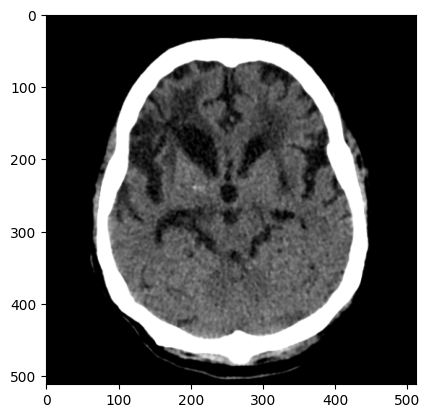

In [58]:
img=preprocessed(resize_image(cv2.imread('C:/Users/mahesh.inamdar/Desktop/codes/classes/run/train/CS_20_thin/CS_20-img-00020-00095.jpg',0),(512,512)))
plt.imshow(img,cmap='gray')

In [28]:

import os
import cv2
from tqdm import tqdm
import numpy as np
from scipy import ndimage
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.utils import shuffle
from xgboost import XGBClassifier
import pickle
from skimage.filters import threshold_otsu
from skimage.segmentation import clear_border
from skimage.morphology import closing, square
from scipy import ndimage
import matplotlib.patches as mpatches
from skimage.color import label2rgb
from skimage.measure import label, regionprops,find_contours
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.utils import shuffle
import matplotlib.pyplot as plt
from skimage.draw import polygon_perimeter
from math import pi, atan2, atan
from lazypredict.Supervised import LazyClassifier

# Define the directories
dir_normal = 'C:\\Users\\yaswa\\learn\\Neural_networks\\research_ws\\Brain_ct_scan\\mal_dataset_thick\\mal_normal'
dir_thin = 'C:\\Users\\yaswa\\learn\\Neural_networks\\research_ws\\Brain_ct_scan\\mal_dataset_thick\\mal_acute'
dir_chronic = 'C:\\Users\\yaswa\\learn\\Neural_networks\\research_ws\\Brain_ct_scan\\mal_dataset_thick\\mal_chronic'

dir_train='C:/Users/mahesh.inamdar/Desktop/codes/classes/run/train'
dir_test='C:/Users/mahesh.inamdar/Desktop/codes/classes/run/test'

def preprocessing(im1):
    im1[im1==255]=0
    im2 = cv2.medianBlur(im1,51)
    th,img2=cv2.threshold(im2, 10, 255, cv2.THRESH_BINARY)
    img2[img2==255]=1
    image=np.multiply(img2,im1)
    thresh = threshold_otsu(image)
    bw = closing(image > thresh, square(3))
    cleared = clear_border(bw)
    label_image = label(cleared)
    image_label_overlay = label2rgb(label_image, image=image, bg_label=0)
    contours = find_contours(image, 0.8)
    bounding_boxes = []
    
    for contour in contours:
        Xmin = np.min(contour[:,0])
        Xmax = np.max(contour[:,0])
        Ymin = np.min(contour[:,1])
        Ymax = np.max(contour[:,1])

        bounding_boxes.append([Xmin, Xmax, Ymin, Ymax])

    with_boxes  = np.copy(image)

    for box in bounding_boxes:
        #[Xmin, Xmax, Ymin, Ymax]
        r = [box[0],box[1],box[1],box[0], box[0]]
        c = [box[3],box[3],box[2],box[2], box[3]]
        rr, cc = polygon_perimeter(r, c, with_boxes.shape)
        with_boxes[rr, cc] = 5 #set color white
        
    #fig, ax = plt.subplots(figsize=(10, 6))
    poly=[]
    
    for region in regionprops(label_image):
        # take regions with large enough areas
        if region.area >= 10000:
                # draw rectangle around segmented coins
            minr, minc, maxr, maxc = region.bbox
            rect = mpatches.Rectangle((minc, minr), maxc - minc, maxr - minr,
                                          fill=False, edgecolor='red', linewidth=2)
            poly.append(region.bbox)
            #ax.add_patch(rect)

    try:
        a,b,c,d=poly[-1]
        return cv2.resize(image[a:c,b:d], (512,512), interpolation= cv2.INTER_LINEAR)
    except IndexError:
        return cv2.resize(image, (512,512), interpolation= cv2.INTER_LINEAR)


def ltp_descriptor(image, radius=3, neighbors=8, threshold=5):
    """
    Compute the Local Ternary Pattern (LTP) descriptor.

    Args:
        image (numpy.ndarray): Input image.
        radius (int): Radius of the neighborhood.
        neighbors (int): Number of neighbors to consider.
        threshold (int): Threshold value for ternary coding.

    Returns:
        numpy.ndarray: LTP descriptor histogram.
    """
    ltp_hist = np.zeros(3 ** neighbors, dtype=np.uint8)
    for y in range(radius, image.shape[0] - radius):
        for x in range(radius, image.shape[1] - radius):
            center = image[y, x]
            code = 0
            for n in range(neighbors):
                x_offset = x + radius * np.cos(2 * pi * n / neighbors)
                y_offset = y - radius * np.sin(2 * pi * n / neighbors)
                neighbor = image[int(y_offset), int(x_offset)]
                code = code * 3 + (neighbor >= center + threshold) + (neighbor <= center - threshold)
            ltp_hist[code] += 1
    return ltp_hist

def lbp_descriptor(image, radius=3, neighbors=8):
    """
    Compute the Local Binary Pattern (LBP) descriptor.

    Args:
        image (numpy.ndarray): Input image.
        radius (int): Radius of the neighborhood.
        neighbors (int): Number of neighbors to consider.

    Returns:
        numpy.ndarray: LBP descriptor histogram.
    """
    lbp_hist = np.zeros(2 ** neighbors, dtype=np.uint8)
    for y in range(radius, image.shape[0] - radius):
        for x in range(radius, image.shape[1] - radius):
            center = image[y, x]
            code = 0
            for n in range(neighbors):
                x_offset = x + radius * np.cos(2 * pi * n / neighbors)
                y_offset = y - radius * np.sin(2 * pi * n / neighbors)
                neighbor = image[int(y_offset), int(x_offset)]
                code = code * 2 + (neighbor >= center)
            lbp_hist[code] += 1
    return lbp_hist

def generate_laplacian_pyramid(image, levels):
    pyramid = []
    for _ in range(levels):
        blurred = cv2.GaussianBlur(image, (7, 7), 0)
        #expanded = cv2.pyrUp(blurred)
        #print(np.shape(expanded),np.shape(blurred))
        difference = cv2.subtract(image, blurred)
        pyramid.append(difference)
        image = blurred  # Update the image for the next iteration
    pyramid.append(image)  # Base of the pyramid (lowest resolution)
    return pyramid

def wld_descriptor(image):
    num_orientations=8
    num_diff_exc_bins=None
    num_segments=6
    num_bins_per_segment=3
    """
    Compute the Weber Local Descriptor (WLD) for the given image.
    
    Args:
        image (numpy.ndarray): Input image.
        num_neighbors (int): Number of neighbors to consider for differential excitation.
        num_orientations (int): Number of dominant orientations to quantize the gradients.
        
    Returns:
        numpy.ndarray: WLD descriptor histogram.
    """
    # Compute differential excitation
    diff_excitation = differential_excitation(image,8)

    # Compute orientation
    orientation = gradient_orientation(image, num_orientations)

    # Replace NaN values in diff_excitation with a suitable value (e.g., 0)
    diff_excitation = np.nan_to_num(diff_excitation, nan=0.0)

    # Set default value for num_diff_exc_bins if None
    num_diff_exc_bins = num_diff_exc_bins or int(np.max(diff_excitation) - np.min(diff_excitation)) + 1

    wld_2d_hist = np.zeros((num_diff_exc_bins, num_orientations))
    for y in range(image.shape[0]):
        for x in range(image.shape[1]):
            j = int(diff_excitation[y, x])
            t = int(orientation[y, x])
            wld_2d_hist[j, t] += 1

    # Encode the 2D histogram into the 1D histogram H
    #wld_1d_hist = encode_2d_to_1d_histogram(wld_2d_hist, num_segments, num_bins_per_segment)

    return np.ravel(np.array(wld_2d_hist))

def encode_2d_to_1d_histogram(wld_2d_hist, num_segments, num_bins_per_segment):
    """
    Encode the 2D WLD histogram into a 1D histogram.

    Args:
        wld_2d_hist (numpy.ndarray): 2D WLD histogram.
        num_segments (int): Number of segments to divide the differential excitation range.
        num_bins_per_segment (int): Number of bins within each differential excitation segment.

    Returns:
        numpy.ndarray: 1D WLD descriptor histogram.
    """
    num_orientations = wld_2d_hist.shape[1]
    diff_exc_range = np.pi
    segment_width = diff_exc_range / num_segments

    # Divide each column (orientation) into segments and concatenate
    wld_1d_hist = []
    for t in range(num_orientations):
        column_hist = wld_2d_hist[:, t]
        segments = np.array_split(column_hist, num_segments)
        for segment in segments:
            if segment.size > 0:  # Check if segment is not empty
                segment_min = segment.min()
                segment_max = segment.max()
                segment_bins = np.linspace(segment_min, segment_max, num_bins_per_segment + 1, endpoint=True)
                segment_hist, _ = np.histogram(segment, bins=segment_bins, density=True)
                wld_1d_hist.extend(segment_hist)
            else:
                # If segment is empty, assign default values to the corresponding bins
                wld_1d_hist.extend([0.0] * num_bins_per_segment)

    return np.array(wld_1d_hist)

def differential_excitation(image, num_neighbors):
    """
    Compute the differential excitation component of the WLD descriptor.
    
    Args:
        image (numpy.ndarray): Input image.
        num_neighbors (int): Number of neighbors to consider.
        
    Returns:
        numpy.ndarray: Differential excitation values.
    """
    diff_excitation = np.zeros_like(image, dtype=np.float64)
    for y in range(image.shape[0]):
        for x in range(image.shape[1]):
            neighbors = []
            for dy in [-1, 0, 1]:
                for dx in [-1, 0, 1]:
                    if dy == dx == 0:
                        continue
                    ny, nx = y + dy, x + dx
                    if 0 <= ny < image.shape[0] and 0 <= nx < image.shape[1]:
                        neighbors.append(image[ny, nx])
            neighbors = np.array(neighbors)
            diff_excitation[y, x] = np.arctan(np.sum(neighbors - image[y, x]) / (image[y, x]+1e-6))
    return diff_excitation

def gradient_orientation(image, num_orientations):
    """
    Compute the gradient orientation component of the WLD descriptor using the Sobel operator.

    Args:
        image (numpy.ndarray): Input image.
        num_orientations (int): Number of dominant orientations to quantize.

    Returns:
        numpy.ndarray: Gradient orientations.
    """
    # Compute gradients using the Sobel operator
    sobel_x = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=3)
    sobel_y = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=3)

    # Compute gradient orientation
    orientation = np.zeros_like(image, dtype=np.float64)
    for y in range(image.shape[0]):
        for x in range(image.shape[1]):
            dx = sobel_x[y, x]
            dy = sobel_y[y, x]
            orientation[y, x] = (atan2(dy, dx) + pi) % (2 * pi) * num_orientations / (2 * pi)

    return orientation.astype(int)

    
def resize_image(image, target_size=(512, 512)):
    resized_image = cv2.resize(image, target_size)
    return resized_image

def wld_descriptor_multiscale(image):
    """
    Compute the Weber Local Descriptor (WLD) for the given image at multiple scales.

    Args:
        image (numpy.ndarray): Input image.
        num_orientations (int): Number of dominant orientations to quantize.
        num_diff_exc_bins (int, optional): Number of bins for differential excitation values.
            If None, it is set to the maximum intensity value in the image.
        num_segments (int): Number of segments to divide the differential excitation range.
        num_bins_per_segment (int): Number of bins within each differential excitation segment.
        num_scales (int): Number of scales to compute the WLD descriptor.

    Returns:
        numpy.ndarray: 1D concatenated multi-scale WLD descriptor histogram.
    """
    # Create a Gaussian pyramid for the input image
    '''
    pyramid = [image.astype(np.float32)]  # Add the original image as the first level
    for _ in range(num_scales - 1):
        pyramid.append(cv2.pyrDown(pyramid[-1]))
    '''
    num_orientations=8
    num_diff_exc_bins=None 
    num_segments=6
    num_bins_per_segment=3
    num_scales=6
    pyramid = generate_laplacian_pyramid(image, levels=3)
    # Compute WLD descriptor at each scale and concatenate
    wld_descriptors = []
    for img in pyramid:
        #print('check',num_orientations)
        wld_descriptors.append(wld_descriptor(img))

    wld_multiscale = np.concatenate(wld_descriptors)
    return wld_multiscale

def fused_descriptor(image, num_orientations=8, num_diff_exc_bins=None, num_segments=6, num_bins_per_segment=3, ltp_radius=3, num_scales=5,ltp_neighbors=8, ltp_threshold=5, lbp_radius=3, lbp_neighbors=8):
    """
    Compute a fused descriptor combining WLD, LTP, and LBP.

    Args:
        image (numpy.ndarray): Input image.
        num_orientations (int): Number of dominant orientations for WLD.
        num_diff_exc_bins (int, optional): Number of bins for differential excitation values in WLD.
        num_segments (int): Number of segments for differential excitation in WLD.
        num_bins_per_segment (int): Number of bins within each differential excitation segment in WLD.
        ltp_radius (int): Radius of the neighborhood for LTP.
        ltp_neighbors (int): Number of neighbors to consider for LTP.
        ltp_threshold (int): Threshold value for ternary coding in LTP.
        lbp_radius (int): Radius of the neighborhood for LBP.
        lbp_neighbors (int): Number of neighbors to consider for LBP.

    Returns:
        numpy.ndarray: Fused descriptor combining WLD, LTP, and LBP.
    """
    # Compute WLD descriptor
    wld_descriptor_hist = wld_descriptor(image, num_orientations, num_diff_exc_bins, num_segments, num_bins_per_segment)

    # Compute LTP descriptor
    ltp_descriptor_hist = ltp_descriptor(image, ltp_radius, ltp_neighbors, ltp_threshold)

    # Compute LBP descriptor
    lbp_descriptor_hist = lbp_descriptor(image, lbp_radius, lbp_neighbors)

    # Concatenate WLD, LTP, and LBP descriptors
    fused_descriptor_hist = np.concatenate((wld_descriptor_hist, ltp_descriptor_hist, lbp_descriptor_hist))

    return fused_descriptor_hist

def extract_patches(image, patch_size):
    patches = []
    height, width = image.shape[:2]
    for y in range(0, height - patch_size[0] + 1, patch_size[0]):
        for x in range(0, width - patch_size[1] + 1, patch_size[1]):
            patch = image[y:y+patch_size[0], x:x+patch_size[1]]
            patches.append(patch)
    return np.array(patches)


def get_label(dir):
    if 'NS' in dir:
        return 0
    elif 'AS' in dir:
        return 1
    elif 'CS' in dir:
        return 2
'''
print('Laplacian Pyramid')
print('\nTest sampling beings..')
dirpath='C:/Users/mahesh.inamdar/Desktop/codes/classes/run/test'
folders=np.random.choice(os.listdir(dirpath),40)
images=[]
X_test=np.zeros(shape=(100,8633))
y_test=[]
c=0
while c<100:
    n=np.random.choice(folders,1)
    img=np.random.choice(os.listdir(os.path.join(dirpath,n[0])),1)
    w=wld_descriptor_multiscale(preprocessing(resize_image(cv2.imread(os.path.join(dirpath,n[0],img[0]),0),(512,512))))
    X_test[c,0:len(w)]=w
    y_test.append(get_label(n[0]))
    if c!=100:
        c+=1
    if c>100:
        break
    

print('Train sampling beings..')
dirpath='C:/Users/mahesh.inamdar/Desktop/codes/classes/run/train'
folders=np.random.choice(os.listdir(dirpath),10)
images=[]
X_train=np.zeros(shape=(150,8633))
y_train=[]
a,no,c,N=0,0,0,0
while N<150:
    if N>150:
        break
    if N!=150:
        N+=1
    n=np.random.choice(folders,1)
    y_train.append(get_label(n[0]))
    if 'AS' in n[0] and a<50:
        img=np.random.choice(os.listdir(os.path.join(dirpath,n[0])),1)
        w=wld_descriptor_multiscale(preprocessing(resize_image(cv2.imread(os.path.join(dirpath,n[0],img[0]),0),(512,512))))
        X_train[N,0:len(w)]=w
        a+=1
    elif 'NS' in n[0] and no<50:
        img=np.random.choice(os.listdir(os.path.join(dirpath,n[0])),1)
        w=wld_descriptor_multiscale(preprocessing(resize_image(cv2.imread(os.path.join(dirpath,n[0],img[0]),0),(512,512))))
        X_train[N,0:len(w)]=w
        no+=1
    elif 'CS' in n[0] and c<50:
        img=np.random.choice(os.listdir(os.path.join(dirpath,n[0])),1)
        w=wld_descriptor_multiscale(preprocessing(resize_image(cv2.imread(os.path.join(dirpath,n[0],img[0]),0),(512,512))))
        X_train[N,0:len(w)]=w
        c+=1
    
    

clf=LazyClassifier(verbose=0,ignore_warnings=True)
models,predictions=clf.fit(X_train,X_test,y_train,y_test)
print(models)
'''
'''
img=preprocessing(resize_image(cv2.imread('C:/Users/mahesh.inamdar/Desktop/codes/classes/run/train/AS_01_thin/Anonymize.Seq3.Ser202.Img145.jpg',0),(512,512)))
W=wld_descriptor_multiscale(img,num_orientations=8, num_diff_exc_bins=None,num_scales=3, num_segments=6, num_bins_per_segment=3)
print(np.shape(W))
'''

"\nimg=preprocessing(resize_image(cv2.imread('C:/Users/mahesh.inamdar/Desktop/codes/classes/run/train/AS_01_thin/Anonymize.Seq3.Ser202.Img145.jpg',0),(512,512)))\nW=wld_descriptor_multiscale(img,num_orientations=8, num_diff_exc_bins=None,num_scales=3, num_segments=6, num_bins_per_segment=3)\nprint(np.shape(W))\n"

In [33]:
for i in range(10):
    print('Checking Traditional WLD\n')
    print('Iteration number',i)
    print('Train sampling beings..')
    dirpath='C:/Users/mahesh.inamdar/Desktop/codes/classes/run/train'
    folders=np.random.choice(os.listdir(dirpath),10)
    images=[]
    X_train=np.zeros(shape=(225,64))
    y_train=[]
    a,no,c,N=0,0,0,0
    while N<225:
        if N>225:
            break
        if N<225:
            N+=1
        n=np.random.choice(folders,1)
        y_train.append(get_label(n[0]))
        if 'AS' in n[0] and a<75:
            imgchoice=np.random.choice(os.listdir(os.path.join(dirpath,n[0])),1)
            img=preprocessing(resize_image(cv2.imread(os.path.join(dirpath,n[0],imgchoice[0]),0),(512,512)))
            patches=extract_patches(img,(256,256))
            w=np.concatenate((wld_descriptor(patches[0]),wld_descriptor(patches[1]),
                                    wld_descriptor(patches[2]),wld_descriptor(patches[3])))
            #w=wld_descriptor(preprocessing(resize_image(cv2.imread(os.path.join(dirpath,n[0],img[0]),0),(512,512))))
            X_train[N,0:len(w)]=w
            a+=1
        elif 'NS' in n[0] and no<75:
            imgchoice=np.random.choice(os.listdir(os.path.join(dirpath,n[0])),1)
            img=preprocessing(resize_image(cv2.imread(os.path.join(dirpath,n[0],imgchoice[0]),0),(512,512)))
            patches=extract_patches(img,(256,256))
            w=np.concatenate((wld_descriptor(patches[0]),wld_descriptor(patches[1]),
                                    wld_descriptor(patches[2]),wld_descriptor(patches[3])))
            #w=wld_descriptor(preprocessing(resize_image(cv2.imread(os.path.join(dirpath,n[0],img[0]),0),(512,512))))
            X_train[N,0:len(w)]=w
            no+=1
        elif 'CS' in n[0] and c<75:
            imgchoice=np.random.choice(os.listdir(os.path.join(dirpath,n[0])),1)
            img=preprocessing(resize_image(cv2.imread(os.path.join(dirpath,n[0],imgchoice[0]),0),(512,512)))
            patches=extract_patches(img,(256,256))
            w=np.concatenate((wld_descriptor(patches[0]),wld_descriptor(patches[1]),
                                    wld_descriptor(patches[2]),wld_descriptor(patches[3])))
            #w=wld_descriptor(preprocessing(resize_image(cv2.imread(os.path.join(dirpath,n[0],img[0]),0),(512,512))))
            X_train[N,0:len(w)]=w
            c+=1
    
    
    
    print('Test sampling beings..')
    dirpath='C:/Users/mahesh.inamdar/Desktop/codes/classes/run/test'
    folders=np.random.choice(os.listdir(dirpath),40)
    images=[]
    X_test=np.zeros(shape=(100,64))
    y_test=[]
    c=0
    while c<100:
        n=np.random.choice(folders,1)
        imgchoice=np.random.choice(os.listdir(os.path.join(dirpath,n[0])),1)
        img=preprocessing(resize_image(cv2.imread(os.path.join(dirpath,n[0],imgchoice[0]),0),(512,512)))
        patches=extract_patches(img,(256,256))
        w=np.concatenate((wld_descriptor(patches[0]),wld_descriptor(patches[1]),
                                    wld_descriptor(patches[2]),wld_descriptor(patches[3])))
        X_test[c,0:len(w)]=w
        y_test.append(get_label(n[0]))
        if c!=100:
            c+=1
        if c>100:
            break
    
    clf=LazyClassifier(verbose=0,ignore_warnings=True)
    models,predictions=clf.fit(X_train,X_test,y_train,y_test)
    print(models)

Checking Traditional WLD

Iteration number 0
Train sampling beings..
Test sampling beings..


 97%|███████████████████████████████████████████████████████████████████████████████▏  | 28/29 [00:01<00:00, 19.70it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000318 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2710
[LightGBM] [Info] Number of data points in the train set: 225, number of used features: 64
[LightGBM] [Info] Start training from score -1.355657
[LightGBM] [Info] Start training from score -0.412154
[LightGBM] [Info] Start training from score -2.525729
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No fu

100%|██████████████████████████████████████████████████████████████████████████████████| 29/29 [00:01<00:00, 19.81it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

KeyboardInterrupt: 

In [31]:
print('Test sampling beings..')
dirpath='C:/Users/mahesh.inamdar/Desktop/codes/classes/run/test'
folders=np.random.choice(os.listdir(dirpath),40)
images=[]
X_test=np.zeros(shape=(100,64))
y_test=[]
c=0
while c<100:
    n=np.random.choice(folders,1)
    imgchoice=np.random.choice(os.listdir(os.path.join(dirpath,n[0])),1)
    img=preprocessing(resize_image(cv2.imread(os.path.join(dirpath,n[0],imgchoice[0]),0),(512,512)))
    patches=extract_patches(img,(256,256))
    w=np.concatenate((wld_descriptor(patches[0]),wld_descriptor(patches[1]),
                                    wld_descriptor(patches[2]),wld_descriptor(patches[3])))
    X_test[c,0:len(w)]=w
    y_test.append(get_label(n[0]))
    if c!=100:
        c+=1
    if c>100:
        break
    
clf=LazyClassifier(verbose=0,ignore_warnings=True)
models,predictions=clf.fit(X_train,X_test,y_train,y_test)
print(models)

Test sampling beings..


100%|██████████████████████████████████████████████████████████████████████████████████| 29/29 [00:01<00:00, 23.31it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000326 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2067
[LightGBM] [Info] Number of data points in the train set: 150, number of used features: 64
[LightGBM] [Info] Start training from score -2.120264
[LightGBM] [Info] Start training from score -0.499776
[LightGBM] [Info] Start training from score -1.297063
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No fu

In [34]:
dirpath='C:/Users/mahesh.inamdar/Desktop/codes/classes/run/train'
folders=np.random.choice(os.listdir(dirpath),40)
images=[]
X_train=np.zeros(shape=(200,64))
y_train=[]
c=0
while c<=200:
    if c>200:
        break
    n=np.random.choice(folders,1)
    imgchoice=np.random.choice(os.listdir(os.path.join(dirpath,n[0])),1)
    img=preprocessing(resize_image(cv2.imread(os.path.join(dirpath,n[0],imgchoice[0]),0),(512,512)))
    patches=extract_patches(img,(256,256))
    w=np.concatenate((wld_descriptor(patches[0]),wld_descriptor(patches[1]),
                                    wld_descriptor(patches[2]),wld_descriptor(patches[3])))
    X_train[c,0:len(w)]=w
    y_train.append(get_label(n[0]))
    c+=1

dirpath='C:/Users/mahesh.inamdar/Desktop/codes/classes/run/test'
folders=np.random.choice(os.listdir(dirpath),40)
images=[]
X_test=np.zeros(shape=(50,64))
y_test=[]
c=0
while c<=50:
    if c>50:
        break
    n=np.random.choice(folders,1)
    imgchoice=np.random.choice(os.listdir(os.path.join(dirpath,n[0])),1)
    img=preprocessing(resize_image(cv2.imread(os.path.join(dirpath,n[0],imgchoice[0]),0),(512,512)))
    patches=extract_patches(img,(256,256))
    w=np.concatenate((wld_descriptor(patches[0]),wld_descriptor(patches[1]),
                                    wld_descriptor(patches[2]),wld_descriptor(patches[3])))
    X_test[c,0:len(w)]=w
    y_test.append(get_label(n[0]))
    c+=1

clf=LazyClassifier(verbose=0,ignore_warnings=True)
models,predictions=clf.fit(X_train,X_test,y_train,y_test)
print(models)

IndexError: index 200 is out of bounds for axis 0 with size 200

In [35]:
dirpath='C:/Users/mahesh.inamdar/Desktop/codes/classes/run/test'
folders=np.random.choice(os.listdir(dirpath),40)
images=[]
X_test=np.zeros(shape=(50,64))
y_test=[]
c=0
while c<=50:
    if c>50:
        break
    n=np.random.choice(folders,1)
    imgchoice=np.random.choice(os.listdir(os.path.join(dirpath,n[0])),1)
    img=preprocessing(resize_image(cv2.imread(os.path.join(dirpath,n[0],imgchoice[0]),0),(512,512)))
    patches=extract_patches(img,(256,256))
    w=np.concatenate((wld_descriptor(patches[0]),wld_descriptor(patches[1]),
                                    wld_descriptor(patches[2]),wld_descriptor(patches[3])))
    X_test[c,0:len(w)]=w
    y_test.append(get_label(n[0]))
    c+=1



IndexError: index 50 is out of bounds for axis 0 with size 50

In [36]:
clf=LazyClassifier(verbose=0,ignore_warnings=True)
models,predictions=clf.fit(X_train,X_test,y_train,y_test)
print(models)

 97%|███████████████████████████████████████████████████████████████████████████████▏  | 28/29 [00:00<00:00, 29.76it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000422 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3592
[LightGBM] [Info] Number of data points in the train set: 200, number of used features: 64
[LightGBM] [Info] Start training from score -0.787458
[LightGBM] [Info] Start training from score -0.843970
[LightGBM] [Info] Start training from score -2.162823
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No fu

100%|██████████████████████████████████████████████████████████████████████████████████| 29/29 [00:01<00:00, 25.21it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

In [80]:
import pandas as pd
df1=pd.read_csv('C:/Users/mahesh.inamdar/Desktop/codes/classes/run/feature_histW2ResnetMod_train.csv')
df2=pd.read_csv('C:/Users/mahesh.inamdar/Desktop/codes/Sets/Set 9010/feature_histW2ResnetModWLDSet9010_train.csv')
X_train1=df1.iloc[:,2304:2305].values
y_train1=df1.iloc[:,2304].values
X_train2=df2.iloc[:,2304:2305].values
y_train2=df2.iloc[:,2304].values
df3=pd.read_csv('C:/Users/mahesh.inamdar/Desktop/codes/classes/run/feature_histW2ResnetMod_test.csv')
df4=pd.read_csv('C:/Users/mahesh.inamdar/Desktop/codes/Sets/Set 9010/feature_histW2ResnetModWLDSet9010_test.csv')
X_test1=df3.iloc[:,2304:2305].values
y_test1=df3.iloc[:,2304].values
X_test2=df4.iloc[:,2304:2305].values
y_test2=df4.iloc[:,2304].values

X=np.concatenate((X_train1,X_train2,X_test1,X_test2))
y=np.concatenate((y_train1,y_test1,y_train2,y_test2))

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.7,shuffle=True)
clf=LazyClassifier(verbose=0,ignore_warnings=True)
models,predictions=clf.fit(X_train,X_test,y_train,y_test)
print(models)

100%|██████████████████████████████████████████████████████████████████████████████████| 29/29 [00:03<00:00,  7.93it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000116 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4
[LightGBM] [Info] Number of data points in the train set: 2908, number of used features: 1
[LightGBM] [Info] Start training from score -0.643506
[LightGBM] [Info] Start training from score -1.725246
[LightGBM] [Info] Start training from score -1.215966
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No furth

In [73]:
df1=pd.read_csv('C:/Users/mahesh.inamdar/Desktop/codes/classes/run/feature_histW2ResnetMod_train.csv')

X_train=df1.iloc[:,2304:2305].values
y_train=df1.iloc[:,2304].values

df3=pd.read_csv('C:/Users/mahesh.inamdar/Desktop/codes/classes/run/feature_histW2ResnetMod_test.csv')

X_test=df3.iloc[:,2304:2305].values
y_test=df3.iloc[:,2304].values

for i in range(10):
    X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,shuffle=False)
    clf=LazyClassifier(verbose=0,ignore_warnings=True)
    models,predictions=clf.fit(X_train,X_test,y_train,y_test)
    print(models)

100%|██████████████████████████████████████████████████████████████████████████████████| 29/29 [00:07<00:00,  3.73it/s]


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000114 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4
[LightGBM] [Info] Number of data points in the train set: 7756, number of used features: 1
[LightGBM] [Info] Start training from score -0.640656
[LightGBM] [Info] Start training from score -1.709141
[LightGBM] [Info] Start training from score -1.230892
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No furth

100%|██████████████████████████████████████████████████████████████████████████████████| 29/29 [00:07<00:00,  3.72it/s]


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000123 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4
[LightGBM] [Info] Number of data points in the train set: 7756, number of used features: 1
[LightGBM] [Info] Start training from score -0.640656
[LightGBM] [Info] Start training from score -1.709141
[LightGBM] [Info] Start training from score -1.230892
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No furth

100%|██████████████████████████████████████████████████████████████████████████████████| 29/29 [00:07<00:00,  3.69it/s]


...

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000087 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4
[LightGBM] [Info] Number of data points in the train set: 7756, number of used features: 1
[LightGBM] [Info] Start training from score -0.640656
[LightGBM] [Info] Start training from score -1.709141
[LightGBM] [Info] Start training from score -1.230892
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No furth

100%|██████████████████████████████████████████████████████████████████████████████████| 29/29 [00:07<00:00,  3.70it/s]


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000127 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4
[LightGBM] [Info] Number of data points in the train set: 7756, number of used features: 1
[LightGBM] [Info] Start training from score -0.640656
[LightGBM] [Info] Start training from score -1.709141
[LightGBM] [Info] Start training from score -1.230892
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No furth

100%|██████████████████████████████████████████████████████████████████████████████████| 29/29 [00:07<00:00,  3.70it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000118 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4
[LightGBM] [Info] Number of data points in the train set: 7756, number of used features: 1
[LightGBM] [Info] Start training from score -0.640656
[LightGBM] [Info] Start training from score -1.709141
[LightGBM] [Info] Start training from score -1.230892
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No furth

In [49]:
X=np.concatenate((X_train,X_test))
y=np.concatenate((y_train,y_test))
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,shuffle=True)
clf=LazyClassifier(verbose=0,ignore_warnings=True)
models,predictions=clf.fit(X_train,X_test,y_train,y_test)
print(models)

100%|██████████████████████████████████████████████████████████████████████████████████| 29/29 [00:01<00:00, 14.55it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000133 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4
[LightGBM] [Info] Number of data points in the train set: 3393, number of used features: 1
[LightGBM] [Info] Start training from score -0.651300
[LightGBM] [Info] Start training from score -1.693319
[LightGBM] [Info] Start training from score -1.221714
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No furth